# Göz Retinası Görüntülerinde Damar Yapısı Belirginleştirme ve Analizi

## 1) Projenin Problemi ve Motivasyonu
Renkli fundus (retina) görüntüleri, insan vücudunda damar ağını **invaziv olmayan** şekilde doğrudan gözlemleyebildiğimiz nadir görüntüleme türlerinden biridir. Retina damarları; çap, yoğunluk, dallanma yapısı, kıvrımlılık (tortuozite) ve mikrodamar paternleri gibi nicel özellikleri sayesinde hem oftalmolojide hem de sistemik hastalıklarla ilişkili mikrodamar değişimlerinin incelenmesinde önemli bir biyobelirteç kaynağıdır.

Retina damarlarının **otomatik ve güvenilir şekilde segmentasyonu** (damar piksellerinin ayrıştırılması), çok sayıda ileri çalışmanın “zorunlu ilk adımıdır”: damar morfolojisi ölçümleri, risk göstergeleri, longitudinal takip, görüntü kalitesi standardizasyonu ve klinik karar destek sistemleri bu çıktıyı temel alır.

## 2) Retina Damar Segmentasyonu ve Analizi Ne İşe Yarar?
Damar segmentasyonu çıktı maske(leri) üzerinden aşağıdaki nicel analizler yapılabilir:
- **Vessel Density (Damar Yoğunluğu):** Retina görüş alanı (FOV) içinde damar piksel oranı
- **Skeleton Tabanlı Uzunluk:** Damar ağının 1-piksel iskeletine indirgenmesi ile toplam uzunluk ölçümü
- **Dallanma (Branch/Junction) Sayısı:** Damar ağının bağlantısallığı ve kompleksliği hakkında temel gösterge

Bu tür ölçümler; örneğin hipertansiyon/diabet gibi durumlarda mikrodamar değişimlerini araştırma düzeyinde nicel olarak karşılaştırmak, farklı hasta gruplarını ayırmak veya zaman içindeki değişimi izlemek için altyapı oluşturur. Bu proje doğrudan “hastalık teşhisi” hedeflemez; teşhis modellerine temel olan **damar çıkarımı ve nicel damar analizi** katmanını hedefler.

## 3) Projenin Amacı ve Hedefleri
Bu projenin amacı, retina görüntülerinde damar yapısını otomatik olarak segment etmek ve temel damar metriklerini üretmektir.

Ana hedefler:
1. **Segmentasyon Modeli Eğitimi:** Fundus görüntüsünden damar maskesi üreten bir model geliştirmek.
2. **Objektif Değerlendirme:** Uzman tarafından üretilmiş GT (ground truth) maskeleri ile karşılaştırıp performansı ölçmek.
3. **Görsel ve Sayısal Analiz:** Sadece tek bir skor vermek yerine, overlay ve hata haritaları (TP/FP/FN) ile model davranışını açıklamak.
4. **Damar Analizi Çıktıları:** GT ve model tahmin maskeleri üzerinden vessel density, skeleton length ve branch point gibi metrikleri çıkarıp raporlamak.

## 4) Veri Seti: FIVES
Bu projede **FIVES** veri seti kullanılmıştır.
- Toplam: 800 retina görüntüsü
- Eğitim: 600 görüntü (train/validation split ile kullanılır)
- Test: 200 görüntü (nihai performans için ayrılmıştır)
- Her görüntü için uzman anotasyonlu damar GT maskesi mevcuttur.

FIVES seçiminin temel nedeni, test tarafında da GT bulunması sayesinde modelin başarısının ölçülebilir olmasıdır.

## 5) Yöntem Özeti (Notebook Pipeline)
Notebook boyunca izlenen işlem hattı aşağıdaki gibidir:

1. **Veri İndirme ve Klasör Tespiti:** KaggleHub ile veri indirilir, train/test image ve GT klasörleri otomatik bulunur.
2. **Eşleşme Kontrolü (Image ↔ GT):** Segmentasyon projelerinde en kritik hatalardan biri “yanlış image-mask eşleşmesi”dir; bu nedenle dosya isimleri baz alınarak eşleşme doğrulanır.
3. **Ön İşleme (FOV + Crop + Resize):**
   - Retina dışı siyah alanların eğitimi yanıltmasını önlemek için FOV (ROI) maskesi çıkarılır.
   - Colab kaynak sınırları ve hız gereksinimi nedeniyle, patch yaklaşımı yerine tüm görüntü üzerinden çalışmak için çözünürlük düşürülerek **512×512** ölçeğine getirilir.
4. **Model:** U-Net tabanlı segmentasyon modeli (baseline).
5. **Kayıp Fonksiyonu:** BCE + Dice (sınıf dengesizliği ve overlap optimizasyonu için).
6. **Metrikler (FOV içinde):** Dice, IoU, Precision, Recall.
7. **Test ve Sunum Çıktıları:** En iyi checkpoint yüklenir, test seti metrikleri hesaplanır ve overlay + hata haritası görselleri üretilir.
8. **Damar Analizi:** GT ve tahmin maskelerinden vessel density, skeleton length ve branch points metrikleri çıkarılır.

## 6) Notlar ve Sınırlılıklar
- GT anotasyonları pratikte bazı ince damarları eksik temsil edebilir. Bu durum modelin “fazladan damar çizmesi” halinde metriklerde FP artışı olarak görünebilir.
- Bu nedenle proje yalnızca sayısal skorları değil, **hata haritaları ve damar analizi çıktıları** ile desteklenen yorumlamayı da içerir.

## 7) Çıktılar
Notebook sonunda otomatik üretilen çıktılar:
- En iyi model checkpoint’i (`best_unet.pt`)
- Eğitim eğrileri ve test örnek görselleri (overlay + error map)
- Test metrik tabloları (CSV)
- GT vs Pred damar analizi tabloları (CSV)
- `exports/` ve `checkpoints/` klasörleri (Drive’a kopyalanabilir)


In [1]:
# ============================================================
# 1) ORTAM KURULUMU + TEMEL AYARLAR
# ============================================================
# Bu hücre:
# - Gerekli paketleri yükler
# - GPU durumunu kontrol eder
# - Çalışma klasörlerini oluşturur
# - Deney tekrarlanabilirliği için seed ayarlar

!pip -q install -U kagglehub albumentations opencv-python-headless scikit-image tqdm

import os, random
from pathlib import Path

import numpy as np
import torch

# ---- Donanım kontrolü ----
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

# ---- Seed: aynı notebook tekrar çalışınca benzer sonuçlar almak için ----
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.benchmark = True  # genelde hız avantajı sağlar

# ---- Proje klasörleri (çıktıları düzenli tutmak için) ----
BASE_DIR = Path("/content")
EXP_DIR  = BASE_DIR / "exports"
FIG_DIR  = EXP_DIR / "figures"
TAB_DIR  = EXP_DIR / "tables"
PRED_DIR = EXP_DIR / "preds"
CKPT_DIR = BASE_DIR / "checkpoints"

for d in [FIG_DIR, TAB_DIR, PRED_DIR, CKPT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("Folders ready:")
print("EXP_DIR:", EXP_DIR)
print("CKPT_DIR:", CKPT_DIR)

# ---- Proje hiperparametreleri (şimdilik temel) ----
IMG_SIZE   = 512   # eğitimde kullanılacak boyut
BATCH_SIZE = 4     # Colab GPU durumuna göre sonra ayarlarız


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.6/13.6 MB 113.8 MB/s eta 0:00:00
Device: cuda
GPU: Tesla T4
Folders ready:
EXP_DIR: /content/exports
CKPT_DIR: /content/checkpoints


## 2) Veri Setini İndirme (KaggleHub)

Bu projede **FIVES** retina damar segmentasyonu veri seti kullanılmaktadır. Veri setinde her fundus görüntüsünün karşılığı olan **uzman anotasyonlu damar maskesi (GT)** bulunduğu için, model performansını objektif metriklerle ölçebiliriz.

Kaggle üzerinde veri seti sürüm/dizin yapısı zamanla değişebildiği için, burada veriyi **kagglehub** ile indirip indirilen dizin yolunu yazdırıyoruz.  
Bu yol, sonraki adımda “train/test görüntü klasörlerini” ve “GT klasörlerini” otomatik bulmak için kullanılacaktır.

Notlar:
- Colab oturumu (runtime) yeniden başlarsa `/content` altındaki dosyalar sıfırlanabilir. Bu yüzden eğitim sonunda model ve çıktıları Google Drive’a kopyalıyoruz.
- Derste eğitim yapmak yerine, Drive’a kaydedilmiş `best_unet.pt` ile yalnızca “yükle ve test et” akışını kullanacağız.


In [2]:
# ============================================================
# 2) VERİYİ İNDİR (kagglehub)
# ============================================================
import kagglehub

dataset_root = Path(kagglehub.dataset_download("nitishsingla0/fives-dataset"))
print("Dataset root:", dataset_root)


100%|██████████| 1.64G/1.64G [00:43<00:00, 40.7MB/s]

Extracting files...


Dataset root: /root/.cache/kagglehub/datasets/nitishsingla0/fives-dataset/versions/1


## 3) Dizin Yapısı ve Klasörlerin Otomatik Tespiti

Segmentasyon projelerinde en kritik problemlerden biri, veri setinin farklı kaynaklarda/dosyalanma biçimlerinde küçük değişiklikler göstermesidir.
Bu yüzden sabit bir klasör ismine güvenmek yerine, indirilen kök dizin altında:

- Eğitim görüntü klasörü (train images)
- Eğitim GT klasörü (train masks / ground truth)
- Test görüntü klasörü (test images)
- Test GT klasörü (test masks / ground truth)

gibi bileşenleri **otomatik olarak tespit ediyoruz**.

Bu yaklaşımın avantajı:
- Notebook’u farklı ortamlarda (Colab / Kaggle / local) daha az kırılgan hale getirir.
- Derste “dosya yolu bulamadı” gibi gereksiz zaman kaybını önler.


In [3]:
# ============================================================
# 3) DATASET YAPISINI GÖR (tree benzeri)
# ============================================================
def show_tree(root: Path, max_depth=3, max_files_per_dir=8):
    root = Path(root)
    print(root)
    for dirpath, dirnames, filenames in os.walk(root):
        dirpath = Path(dirpath)
        depth = len(dirpath.relative_to(root).parts)
        if depth > max_depth:
            dirnames[:] = []
            continue

        indent = "  " * depth
        print(f"{indent}- {dirpath.name}/")

        # dosyaları sınırlı göster
        for f in sorted(filenames)[:max_files_per_dir]:
            print(f"{indent}  • {f}")
        if len(filenames) > max_files_per_dir:
            print(f"{indent}  • ... ({len(filenames)} files total)")

show_tree(dataset_root, max_depth=4, max_files_per_dir=6)


/root/.cache/kagglehub/datasets/nitishsingla0/fives-dataset/versions/1
- 1/
  - FIVES A Fundus Image Dataset for AI-based Vessel Segmentation/
    - FIVES A Fundus Image Dataset for AI-based Vessel Segmentation/
      • Quality Assessment.xlsx
      - train/
        - Ground truth/
          • 100_A.png
          • 101_A.png
          • 102_A.png
          • 103_A.png
          • 104_A.png
          • 105_A.png
          • ... (600 files total)
        - Original/
          • 100_A.png
          • 101_A.png
          • 102_A.png
          • 103_A.png
          • 104_A.png
          • 105_A.png
          • ... (600 files total)
      - test/
        - Ground truth/
          • 100_D.png
          • 101_G.png
          • 102_G.png
          • 103_G.png
          • 104_G.png
          • 105_G.png
          • ... (200 files total)
        - Original/
          • 100_D.png
          • 101_G.png
          • 102_G.png
          • 103_G.png
          • 104_G.png
          • 105_G.png
         

## 4) Image–Mask (GT) Eşleşmesini Doğrulama (Sanity Check)

Segmentasyon eğitiminde en tehlikeli hata şudur:
> Görüntüler ile maskelerin yanlış eşleşmesi (ör. image_012.tif ile mask_013.png).

Bu hata modelin eğitimini anlamsız hale getirir ve metrikleri rastgeleleştirir.  
Bu nedenle bu adımda:

1. Görüntü dosyalarının “stem” (uzantısız isim) listesini çıkarıyoruz.
2. GT dosyalarının “stem” listesini çıkarıyoruz.
3. Ortak stem’leri kullanarak **1-1 eşleşen çiftleri** oluşturuyoruz.
4. Eksik/çakışan örnekleri raporluyoruz.

Bu kontrol sayesinde:
- Train/val/test ayrımı güvenilir olur.
- Hesaplanan Dice/IoU/Precision/Recall metrikleri gerçekten anlamlı olur.


In [4]:
# ============================================================
# 4) ADAY IMAGE/MASK KLASÖRLERİNİ LİSTELE
# ============================================================
IMG_EXT = {".png", ".jpg", ".jpeg", ".tif", ".tiff", ".bmp"}

def count_images_in_dir(p: Path):
    return sum(1 for x in p.iterdir() if x.is_file() and x.suffix.lower() in IMG_EXT)

candidates = []
for p in dataset_root.rglob("*"):
    if p.is_dir():
        n = count_images_in_dir(p)
        if n >= 50:  # 50+ görüntü içeren klasörleri aday al
            candidates.append((n, p))

candidates = sorted(candidates, key=lambda x: x[0], reverse=True)

print("Top candidate directories (image-like files):")
for i, (n, p) in enumerate(candidates[:30]):
    print(f"[{i:02d}] {n:4d} files -> {p}")


Top candidate directories (image-like files):
[00]  600 files -> /root/.cache/kagglehub/datasets/nitishsingla0/fives-dataset/versions/1/FIVES A Fundus Image Dataset for AI-based Vessel Segmentation/FIVES A Fundus Image Dataset for AI-based Vessel Segmentation/train/Ground truth
[01]  600 files -> /root/.cache/kagglehub/datasets/nitishsingla0/fives-dataset/versions/1/FIVES A Fundus Image Dataset for AI-based Vessel Segmentation/FIVES A Fundus Image Dataset for AI-based Vessel Segmentation/train/Original
[02]  200 files -> /root/.cache/kagglehub/datasets/nitishsingla0/fives-dataset/versions/1/FIVES A Fundus Image Dataset for AI-based Vessel Segmentation/FIVES A Fundus Image Dataset for AI-based Vessel Segmentation/test/Ground truth
[03]  200 files -> /root/.cache/kagglehub/datasets/nitishsingla0/fives-dataset/versions/1/FIVES A Fundus Image Dataset for AI-based Vessel Segmentation/FIVES A Fundus Image Dataset for AI-based Vessel Segmentation/test/Original


In [5]:
# ============================================================
# 4.1) SEÇİM: TRAIN/TEST IMAGE ve MASK DİZİNLERİ
# ============================================================
# Hücre 6 çıktısındaki index'lere göre doldur.
# Örnek:
# TRAIN_IMG_IDX = 0
# TRAIN_MSK_IDX = 1
# TEST_IMG_IDX  = 2
# TEST_MSK_IDX  = 3

TRAIN_IMG_IDX = 1
TRAIN_MSK_IDX = 0
TEST_IMG_IDX  = 3
TEST_MSK_IDX  = 2

def pick(idx):
    if idx is None:
        return None
    return candidates[idx][1]

TRAIN_IMG_DIR = pick(TRAIN_IMG_IDX)
TRAIN_MSK_DIR = pick(TRAIN_MSK_IDX)
TEST_IMG_DIR  = pick(TEST_IMG_IDX)
TEST_MSK_DIR  = pick(TEST_MSK_IDX)

print("TRAIN_IMG_DIR:", TRAIN_IMG_DIR)
print("TRAIN_MSK_DIR:", TRAIN_MSK_DIR)
print("TEST_IMG_DIR :", TEST_IMG_DIR)
print("TEST_MSK_DIR :", TEST_MSK_DIR)


TRAIN_IMG_DIR: /root/.cache/kagglehub/datasets/nitishsingla0/fives-dataset/versions/1/FIVES A Fundus Image Dataset for AI-based Vessel Segmentation/FIVES A Fundus Image Dataset for AI-based Vessel Segmentation/train/Original
TRAIN_MSK_DIR: /root/.cache/kagglehub/datasets/nitishsingla0/fives-dataset/versions/1/FIVES A Fundus Image Dataset for AI-based Vessel Segmentation/FIVES A Fundus Image Dataset for AI-based Vessel Segmentation/train/Ground truth
TEST_IMG_DIR : /root/.cache/kagglehub/datasets/nitishsingla0/fives-dataset/versions/1/FIVES A Fundus Image Dataset for AI-based Vessel Segmentation/FIVES A Fundus Image Dataset for AI-based Vessel Segmentation/test/Original
TEST_MSK_DIR : /root/.cache/kagglehub/datasets/nitishsingla0/fives-dataset/versions/1/FIVES A Fundus Image Dataset for AI-based Vessel Segmentation/FIVES A Fundus Image Dataset for AI-based Vessel Segmentation/test/Ground truth


## 5) Hızlı Ön İzleme (Input–GT–FOV)

Bu bölümün amacı, eğitim başlamadan önce veri ve etiketlerin doğru olduğundan emin olmaktır.

Göstereceğimiz çıktılar:
- **Input fundus görüntüsü:** modelin girdi olarak gördüğü veri
- **GT damar maskesi:** uzman anotasyonu (yer doğrusu)
- **FOV (Field of View) maskesi:** retina dışındaki siyah alanları dışlamak için kullanılan ROI

Neden önemli?
- Damar segmentasyonunda “retina dışı siyah alanlar” (FOV dışı) modele yanlış sinyal verir.
- Metrikleri ve kaybı **yalnızca FOV içinde** hesaplamak, daha adil ve klinik olarak anlamlı değerlendirme sağlar.

Bu ön izleme adımı, ileride çıkabilecek veri kaynaklı hataları (yanlış eşleşme, ters maske, bozuk okuma, hatalı boyut) daha en başta yakalamak için yapılır.


Train images: 600
Train masks : 600
Common pairs: 600


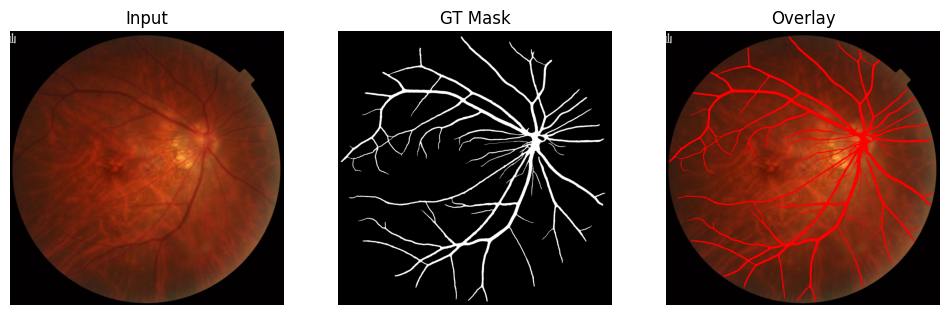

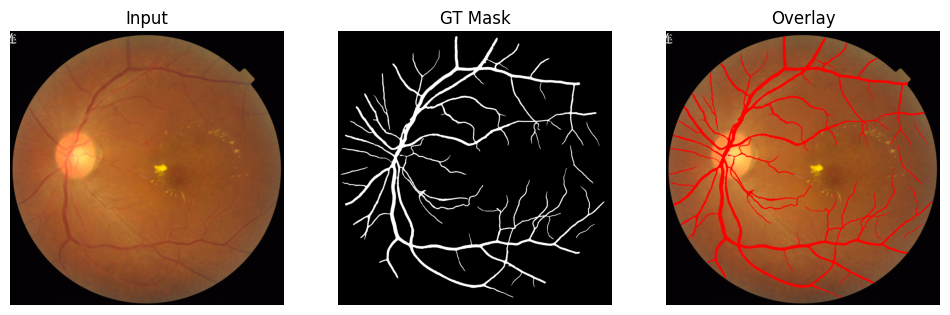

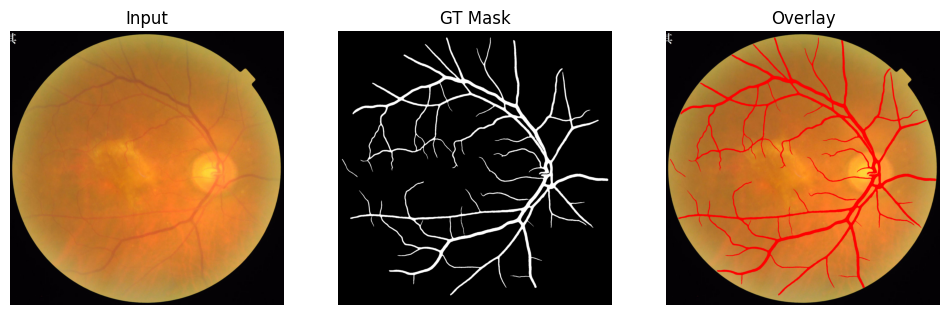

In [7]:
# ============================================================
# 5) EŞLEŞME KONTROLÜ + ÖRNEK GÖRSELLEŞTİRME
# ============================================================
import cv2
import matplotlib.pyplot as plt

def list_images(folder: Path):
    files = [x for x in folder.iterdir() if x.is_file() and x.suffix.lower() in IMG_EXT]
    return sorted(files)

def stem_map(files):
    # "dosya_adi.png" -> "dosya_adi"
    return {f.stem: f for f in files}

def read_rgb(path: Path):
    # OpenCV BGR okur; RGB'ye çeviriyoruz
    img = cv2.imread(str(path), cv2.IMREAD_COLOR)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return img

def read_mask(path: Path):
    # maskeleri grayscale okuyup 0/1 hale getireceğiz
    m = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    # 0/255 veya 0/1 olabilir: ikisini de 0/1'e çek
    m = (m > 0).astype(np.uint8)
    return m

assert TRAIN_IMG_DIR is not None, "Önce TRAIN_IMG_DIR seç!"
assert TRAIN_MSK_DIR is not None, "Önce TRAIN_MSK_DIR seç!"

train_imgs = list_images(TRAIN_IMG_DIR)
train_msks = list_images(TRAIN_MSK_DIR)

print("Train images:", len(train_imgs))
print("Train masks :", len(train_msks))

img_map = stem_map(train_imgs)
msk_map = stem_map(train_msks)

common = sorted(set(img_map.keys()) & set(msk_map.keys()))
print("Common pairs:", len(common))

# birkaç örnek göster
sample = common[:3]  # istersen random da seçebiliriz
for name in sample:
    img = read_rgb(img_map[name])
    msk = read_mask(msk_map[name])

    plt.figure(figsize=(12,4))
    plt.subplot(1,3,1); plt.title("Input"); plt.imshow(img); plt.axis("off")
    plt.subplot(1,3,2); plt.title("GT Mask"); plt.imshow(msk, cmap="gray"); plt.axis("off")

    # overlay: damarları kırmızı göster
    overlay = img.copy()
    overlay[msk==1] = [255, 0, 0]
    plt.subplot(1,3,3); plt.title("Overlay"); plt.imshow(overlay); plt.axis("off")
    plt.show()


## 6) Ön İşleme (Preprocessing): FOV (ROI) + Crop + Resize

Retina fundus görüntülerinde tipik olarak görüntünün büyük bir kısmı retina dışı **siyah/boş alan** içerir. Bu alanlar damar segmentasyonu açısından bilgi taşımaz ve modele gereksiz yük bindirir. Bu nedenle ön işlem hattımızın temel hedefi şudur:

- Öğrenmeyi retina bölgesine odaklamak (FOV içinde çalışmak)
- Hesaplama maliyetini düşürmek
- Eğitim ve test değerlendirmesini daha adil yapmak

### 6.1 FOV (Field of View) / ROI Maskesi Nedir?
FOV maskesi, retina dairesinin bulunduğu bölgeyi 1, geri kalanını 0 yapan ikili bir maskedir.

Bu projede FOV’nin rolü:
- **Loss ve metrik hesaplarını** retina dışını hariç tutacak şekilde yapmak
- Damar analizinde (yoğunluk, uzunluk vb.) yalnızca retina alanını dikkate almak

### 6.2 Neden Crop (Retina Merkezli Kırpma)?
Retina dairesinin etrafında kalan siyah alanlar hem eğitimde gereksiz maliyet yaratır hem de görüntü boyutunu büyütür.
Bu yüzden:
- FOV maskesine göre retina bölgesini kapsayan bir bounding box belirlenir
- Görüntü ve GT aynı bbox ile kırpılır (eşleşme korunur)

### 6.3 Neden Resize (512×512)?
FIVES görüntüleri yüksek çözünürlüklüdür. Colab üzerinde eğitim süresi ve bellek sınırları nedeniyle, patch/tiling yaklaşımına girmeden tüm görüntü üzerinden çalışmak için çözünürlük düşürme uygulanmıştır.

Bu projede hedef:
- Modelin genel damar ağını öğrenmesi
- GT anotasyonlarının zaten çok ince kılcal damarların tamamını temsil etmeyebilmesi nedeniyle “aşırı yüksek çözünürlük” gereksinimini sınırlı tutmak
- Eğitim ve test akışını hızlı ve tekrarlanabilir yapmak

Bu nedenle tüm görüntüler **512×512** boyutuna ölçeklenir ve model eğitiminde bu boyut standartlaştırılır.

> Önemli: Resize işlemi her zaman GT ile aynı dönüşümlerle yapılmalıdır. Aksi halde görüntü–maske hizası bozulur ve eğitim anlamsızlaşır.

### 6.4 Bu adımın çıktıları
Ön işleme sonucunda her örnek için:
- `rgb`: 512×512 normalize edilecek RGB giriş görüntüsü
- `gt`: 512×512 ikili damar maskesi
- `fov`: 512×512 ROI maskesi

Bu üçlü, hem eğitimde hem de değerlendirmede birlikte kullanılır.


In [8]:
# ============================================================
# 6) FOV MASKESİ + CROP + RESIZE (512)
# ============================================================
# Derste anlatım:
# - FOV maskesi: "retina dairesi neresi?" sorusunun cevabı.
# - Crop: siyah alanları atıp bilgiyi 512 piksele daha fazla sığdırmak.
# - Resize: Colab sınırlarında eğitimi mümkün kılmak.
# - En önemli kural: image, GT mask, FOV mask aynı geometrik işlemleri görmeli.

import cv2
import numpy as np

def build_fov_mask(rgb_img):
    """
    Fundus (retina) alanını yaklaşık belirlemek için basit bir yöntem:
    - Yeşil kanal genelde en yüksek kontrastı verir.
    - Otsu eşikleme ile retina dairesi / siyah alan ayrımı yapılabilir.
    - Morfoloji ile maske temizlenir.
    - En büyük bağlı bileşen seçilir (retina alanı).
    """
    g = rgb_img[:, :, 1]  # green channel
    g_blur = cv2.GaussianBlur(g, (5, 5), 0)

    # Otsu threshold: otomatik eşik seçer
    _, thr = cv2.threshold(g_blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # Morfolojik temizlik: küçük delikleri kapat, küçük gürültüyü temizle
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (15, 15))
    thr = cv2.morphologyEx(thr, cv2.MORPH_CLOSE, kernel, iterations=2)
    thr = cv2.morphologyEx(thr, cv2.MORPH_OPEN,  kernel, iterations=1)

    # En büyük bağlı bileşeni seç
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(thr, connectivity=8)
    if num_labels <= 1:
        # Hiç bileşen yoksa (nadir), tüm alanı FOV say
        return np.ones(g.shape, dtype=np.uint8)

    # 0 label background; en büyük non-background component
    areas = stats[1:, cv2.CC_STAT_AREA]
    max_idx = 1 + np.argmax(areas)
    fov = (labels == max_idx).astype(np.uint8)

    return fov  # 0/1

def crop_to_square_by_mask(arr, mask):
    """
    mask'in bounding box'ına göre kare crop.
    - Retina dairesini kapsayan en küçük bbox bulunur.
    - Bbox kareye genişletilir (w ve h eşitlenir).
    - Görüntü sınırları içinde kalacak şekilde kırpılır.
    """
    ys, xs = np.where(mask > 0)
    if len(xs) == 0 or len(ys) == 0:
        # maske boşsa crop yapma
        return arr, mask

    x1, x2 = xs.min(), xs.max()
    y1, y2 = ys.min(), ys.max()

    w = x2 - x1 + 1
    h = y2 - y1 + 1
    side = max(w, h)

    # merkez
    cx = (x1 + x2) // 2
    cy = (y1 + y2) // 2

    half = side // 2
    nx1 = cx - half
    nx2 = nx1 + side
    ny1 = cy - half
    ny2 = ny1 + side

    # sınır düzeltme
    H, W = mask.shape[:2]
    if nx1 < 0:
        nx2 -= nx1
        nx1 = 0
    if ny1 < 0:
        ny2 -= ny1
        ny1 = 0
    if nx2 > W:
        shift = nx2 - W
        nx1 = max(0, nx1 - shift)
        nx2 = W
    if ny2 > H:
        shift = ny2 - H
        ny1 = max(0, ny1 - shift)
        ny2 = H

    if arr.ndim == 3:
        arr_c = arr[ny1:ny2, nx1:nx2, :]
    else:
        arr_c = arr[ny1:ny2, nx1:nx2]

    mask_c = mask[ny1:ny2, nx1:nx2]
    return arr_c, mask_c

def resize_image_and_masks(rgb, gt_mask, fov_mask, out_size=512):
    """
    Resize kuralı:
    - RGB: bilinear (INTER_LINEAR)
    - GT ve FOV: nearest (INTER_NEAREST) (ikili maskeyi bozma!)
    """
    rgb_r = cv2.resize(rgb, (out_size, out_size), interpolation=cv2.INTER_LINEAR)
    gt_r  = cv2.resize(gt_mask, (out_size, out_size), interpolation=cv2.INTER_NEAREST)
    fov_r = cv2.resize(fov_mask, (out_size, out_size), interpolation=cv2.INTER_NEAREST)

    # 0/1 garantisi
    gt_r  = (gt_r > 0).astype(np.uint8)
    fov_r = (fov_r > 0).astype(np.uint8)

    return rgb_r, gt_r, fov_r

def preprocess_pair(img_path, msk_path, out_size=512):
    """
    Tek bir image+mask çifti için komple preprocessing.
    Çıktı: (rgb_512, gt_512, fov_512)
    """
    # image oku (RGB)
    bgr = cv2.imread(str(img_path), cv2.IMREAD_COLOR)
    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)

    # GT oku (grayscale) -> 0/1
    gt = cv2.imread(str(msk_path), cv2.IMREAD_GRAYSCALE)
    gt = (gt > 0).astype(np.uint8)

    # FOV üret
    fov = build_fov_mask(rgb)

    # Kare crop (image, gt, fov aynı crop!)
    rgb_c, fov_c = crop_to_square_by_mask(rgb, fov)
    gt_c,  _     = crop_to_square_by_mask(gt,  fov)  # burada bbox aynı olmalı; pratik için yeniden çağırdık

    # Resize 512
    rgb_r, gt_r, fov_r = resize_image_and_masks(rgb_c, gt_c, fov_c, out_size=out_size)
    return rgb_r, gt_r, fov_r


Common train pairs: 600


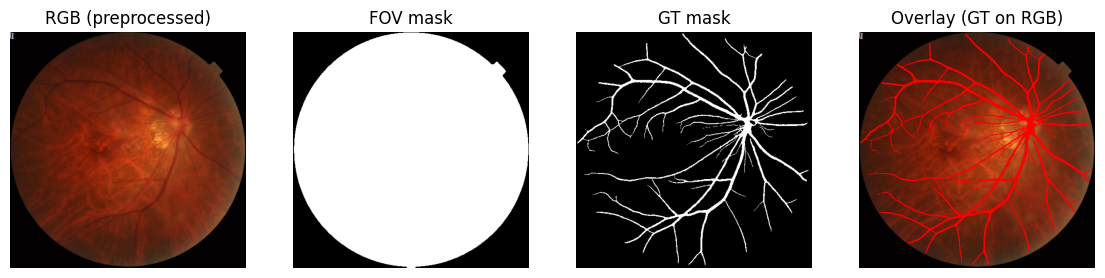

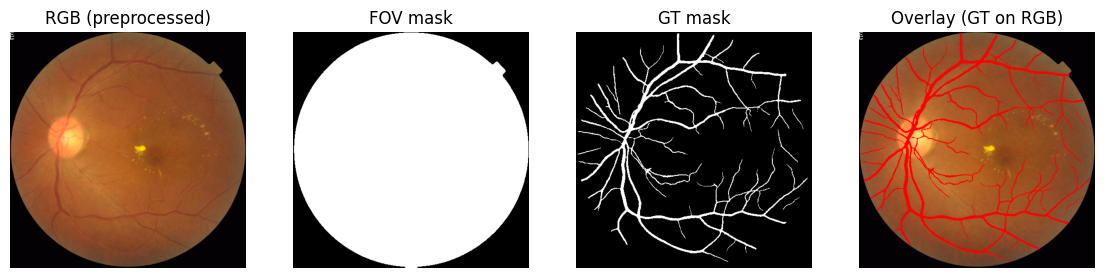

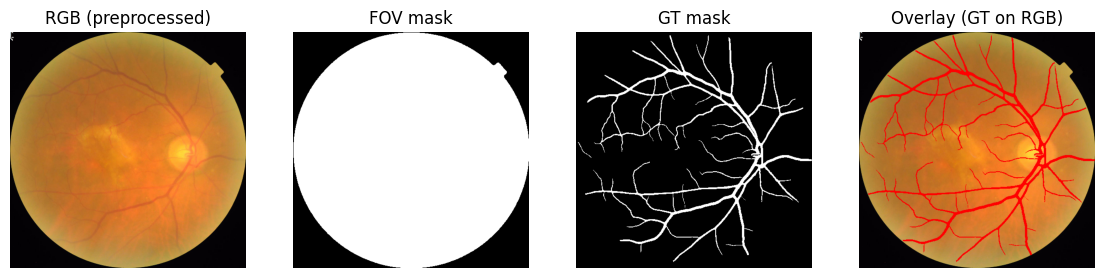

In [9]:
# ============================================================
# 6.1) ÖN İŞLEMEYİ DOĞRULA: örneklerde görüntüle
# ============================================================
import matplotlib.pyplot as plt

# train eşleşmelerinden birkaç örnek alalım
# (sen common listesini daha önce üretmiştin; burada tekrar üretelim)
train_imgs = [x for x in Path(TRAIN_IMG_DIR).iterdir() if x.is_file()]
train_msks = [x for x in Path(TRAIN_MSK_DIR).iterdir() if x.is_file()]

img_map = {p.stem: p for p in train_imgs}
msk_map = {p.stem: p for p in train_msks}
common = sorted(set(img_map.keys()) & set(msk_map.keys()))

print("Common train pairs:", len(common))

# 3 örnek göster
for name in common[:3]:
    rgb, gt, fov = preprocess_pair(img_map[name], msk_map[name], out_size=IMG_SIZE)

    # overlay: tahmini değil GT overlay, sadece kontrol için
    overlay = rgb.copy()
    overlay[gt == 1] = [255, 0, 0]

    plt.figure(figsize=(14,4))
    plt.subplot(1,4,1); plt.title("RGB (preprocessed)"); plt.imshow(rgb); plt.axis("off")
    plt.subplot(1,4,2); plt.title("FOV mask"); plt.imshow(fov, cmap="gray"); plt.axis("off")
    plt.subplot(1,4,3); plt.title("GT mask"); plt.imshow(gt, cmap="gray"); plt.axis("off")
    plt.subplot(1,4,4); plt.title("Overlay (GT on RGB)"); plt.imshow(overlay); plt.axis("off")
    plt.show()


## 7) Train / Validation Ayrımı

Modelin gerçek performansını anlamak için, eğitim verisini ikiye ayırıyoruz:

- **Train set:** model ağırlıklarının güncellendiği bölüm
- **Validation set:** eğitim sırasında modelin “genelleme” performansını ölçtüğümüz bölüm

Neden gerekli?
- Sadece eğitim kaybına bakmak yanıltıcıdır; model ezberleyebilir.
- Validation metrikleri artmayı bırakıp düşmeye başladığında overfitting riski oluşur.

Bu projede:
- 600 eğitim görüntüsü içinden belirli bir oran validation’a ayrılır (ör. %20).
- En iyi model, validation üzerinde en yüksek performans (ör. **val Dice**) elde eden checkpoint olarak seçilir.

> Not: Test seti (200 görüntü) eğitim sürecine dahil edilmez; yalnızca final raporlamada kullanılır.


In [10]:
# ============================================================
# 7) TRAIN/VAL/TEST PAIR LISTELERİ
# ============================================================
# Derste anlatım:
# - Segmentasyonda veri "image_path + mask_path" çiftlerinden oluşur.
# - Split'i dosya isimlerine göre yapıyoruz ki yanlış eşleşme olmasın.
# - Seed ile karıştırıp ayırıyoruz: her çalıştırmada aynı split.

from pathlib import Path

IMG_EXT = {".png", ".jpg", ".jpeg", ".tif", ".tiff", ".bmp"}

def list_files(folder: Path):
    return sorted([x for x in Path(folder).iterdir()
                   if x.is_file() and x.suffix.lower() in IMG_EXT])

def build_pairs(img_dir: Path, msk_dir: Path):
    imgs = list_files(img_dir)
    msks = list_files(msk_dir)
    img_map = {p.stem: p for p in imgs}
    msk_map = {p.stem: p for p in msks}
    common = sorted(set(img_map.keys()) & set(msk_map.keys()))
    pairs = [(img_map[s], msk_map[s], s) for s in common]  # (img_path, msk_path, stem)
    return pairs

# --- train pairs ---
train_pairs = build_pairs(TRAIN_IMG_DIR, TRAIN_MSK_DIR)
print("Total train pairs:", len(train_pairs))

# --- test pairs ---
test_pairs = build_pairs(TEST_IMG_DIR, TEST_MSK_DIR)
print("Total test pairs :", len(test_pairs))

# --- split train -> train/val ---
val_ratio = 0.2
rng = np.random.RandomState(SEED)
idx = np.arange(len(train_pairs))
rng.shuffle(idx)

val_n = int(len(train_pairs) * val_ratio)
val_idx = idx[:val_n]
trn_idx = idx[val_n:]

train_list = [train_pairs[i] for i in trn_idx]
val_list   = [train_pairs[i] for i in val_idx]

print("Train split:", len(train_list))
print("Val split  :", len(val_list))

# kısa kontrol: stem çakışmasın
train_stems = set([s for _,_,s in train_list])
val_stems   = set([s for _,_,s in val_list])
print("Overlap train/val stems:", len(train_stems & val_stems))


Total train pairs: 600
Total test pairs : 200
Train split: 480
Val split  : 120
Overlap train/val stems: 0


## 8) Veri Artırma (Augmentation)

Retina damar segmentasyonu, görüntü kalitesi (aydınlatma, kontrast), cihaz farklılıkları ve çekim koşullarından etkilenebilir.
Eğitim verisini “daha çeşitli” hale getirmek için train tarafında veri artırma uyguluyoruz.

Uygulanan tipik artırmalar:
- Geometrik: yatay/dikey çevirme, küçük rotasyonlar
- Fotometrik: parlaklık/kontrast değişimleri, gamma benzeri değişimler
- (Kontrollü) bulanıklık veya gürültü (opsiyonel)

Bu adımın hedefi:
- Modelin sadece belirli bir görüntü stilini değil, damar yapısının genel paternini öğrenmesi
- Overfitting riskini azaltmak
- Testte daha stabil sonuç almak

Önemli:
- **Augmentation sadece train setinde uygulanır.**
- Validation ve test setinde augmentation yapılmaz; yalnızca preprocessing uygulanır.
- Görüntüye uygulanan geometrik dönüşüm, aynı şekilde GT maskeye de uygulanmalıdır (eşleşme korunmalı).


In [11]:
# ============================================================
# 8) AUGMENTATION (ALBUMENTATIONS)
# ============================================================
import albumentations as A
import cv2
# Not:
# - mask'lerde INTER_NEAREST kullanılır (0/1 bozulmasın)
# - küçük rotasyon/flip, hafif parlaklık-kontrast yeterli
# - aşırı deformasyon damarı "yapay" hale getirir, kaçınıyoruz.

train_tfms = A.Compose(
    [
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.2),
        A.Rotate(limit=15, border_mode=cv2.BORDER_CONSTANT, value=0, mask_value=0, p=0.5),
        A.RandomBrightnessContrast(brightness_limit=0.15, contrast_limit=0.15, p=0.5),
    ],
    additional_targets={"fov": "mask"}  # fov maskesini de "mask" gibi dönüştür
)

# Val/Test: sadece "kimlik" (değişiklik yok)
val_tfms = A.Compose(
    [],
    additional_targets={"fov": "mask"}
)


/tmp/ipython-input-3327048834.py:15: UserWarning: Argument(s) 'value, mask_value' are not valid for transform Rotate
  A.Rotate(limit=15, border_mode=cv2.BORDER_CONSTANT, value=0, mask_value=0, p=0.5),


## 9) Dataset ve DataLoader (Eğitim Akışı)

Bu bölümde PyTorch eğitim döngüsüne uygun bir veri akışı kuruyoruz.

### 9.1 Dataset Sınıfı
Dataset’in görevi:
- Dosya yolundan görüntü ve GT’yi okumak
- Ön işleme (FOV + crop + resize) uygulamak
- Train ise augmentation uygulamak
- Çıktıları modele uygun tensör formatına çevirmek:
  - Input: `(3, H, W)` float (0–1 normalize)
  - GT: `(1, H, W)` ikili maske
  - FOV: `(1, H, W)` ikili maske

Dataset ayrıca her örneğin kimliğini (stem) döndürür. Bu, testte görüntü bazlı sonuçları CSV’ye yazarken ve görsel seçerken kullanılır.

### 9.2 DataLoader
DataLoader, batch üretir:
- `batch_size`: aynı anda işlenen örnek sayısı
- `shuffle`: train’de karıştırma (genelleme için)
- `num_workers`: veri hazırlama paralelliği (GPU’da performans için önemli)

Bu projede batch içeriği:
- `x`: giriş görüntü tensörü
- `y`: GT damar maskesi
- `fov`: ROI maskesi
- `stem`: dosya kimliği (sonuç raporlama için)

Bu yapı sayesinde eğitim, değerlendirme ve görselleştirme adımları aynı format üzerinden ilerler.


In [12]:
# ============================================================
# 9) DATASET SINIFI
# ============================================================
from torch.utils.data import Dataset, DataLoader

def to_tensor_image(rgb_uint8):
    """
    RGB uint8 (H,W,3) -> float32 tensor (3,H,W) in [0,1]
    """
    x = rgb_uint8.astype(np.float32) / 255.0
    x = np.transpose(x, (2, 0, 1))  # C,H,W
    return torch.from_numpy(x)

def to_tensor_mask(mask_uint8):
    """
    mask uint8 (H,W) 0/1 -> float32 tensor (1,H,W)
    """
    m = mask_uint8.astype(np.float32)
    m = np.expand_dims(m, axis=0)  # 1,H,W
    return torch.from_numpy(m)

class FivesVesselDataset(Dataset):
    def __init__(self, pair_list, out_size=512, transform=None):
        """
        pair_list: [(img_path, msk_path, stem), ...]
        transform: albumentations.Compose (image+mask+fov birlikte)
        """
        self.pairs = pair_list
        self.out_size = out_size
        self.transform = transform

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        img_path, msk_path, stem = self.pairs[idx]

        # 1) preprocess: fov + crop + resize (512) + binary GT
        rgb, gt, fov = preprocess_pair(img_path, msk_path, out_size=self.out_size)

        # 2) augmentation (train için)
        if self.transform is not None:
            aug = self.transform(image=rgb, mask=gt, fov=fov)
            rgb, gt, fov = aug["image"], aug["mask"], aug["fov"]

        # 3) tensor dönüşümü
        x  = to_tensor_image(rgb)     # (3,H,W)
        y  = to_tensor_mask(gt)       # (1,H,W)
        fv = to_tensor_mask(fov)      # (1,H,W)

        return x, y, fv, stem


In [13]:
# ============================================================
# 10) DATALOADER OLUŞTUR + HIZLI KONTROL
# ============================================================
num_workers = 2 if torch.cuda.is_available() else 0

train_ds = FivesVesselDataset(train_list, out_size=IMG_SIZE, transform=train_tfms)
val_ds   = FivesVesselDataset(val_list,   out_size=IMG_SIZE, transform=val_tfms)
test_ds  = FivesVesselDataset(test_pairs, out_size=IMG_SIZE, transform=val_tfms)

pin = torch.cuda.is_available()

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=num_workers, pin_memory=pin, drop_last=True)

val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=num_workers, pin_memory=pin)

test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=num_workers, pin_memory=pin)

# ---- sanity check: batch şekilleri ----
x, y, fv, stem = next(iter(train_loader))
print("x :", x.shape, x.dtype)    # (B,3,512,512)
print("y :", y.shape, y.dtype)    # (B,1,512,512)
print("fv:", fv.shape, fv.dtype)  # (B,1,512,512)
print("stem example:", stem[:3])


x : torch.Size([4, 3, 512, 512]) torch.float32
y : torch.Size([4, 1, 512, 512]) torch.float32
fv: torch.Size([4, 1, 512, 512]) torch.float32
stem example: ['529_N', '340_G', '489_N']


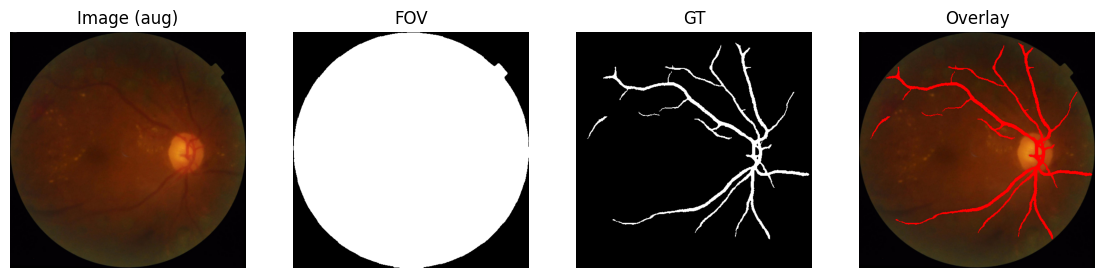

In [14]:
# ============================================================
# 10.1) AUGMENT SONRASI ÖRNEK GÖRSEL KONTROL
# ============================================================
import matplotlib.pyplot as plt

# tek örnek çekelim
x, y, fv, stem = next(iter(train_loader))

# batch'ten 1. örnek
img = x[0].cpu().numpy().transpose(1,2,0)  # H,W,C
gt  = y[0,0].cpu().numpy()
fov = fv[0,0].cpu().numpy()

overlay = (img * 255).astype(np.uint8).copy()
overlay[gt == 1] = [255, 0, 0]

plt.figure(figsize=(14,4))
plt.subplot(1,4,1); plt.title("Image (aug)"); plt.imshow(img); plt.axis("off")
plt.subplot(1,4,2); plt.title("FOV"); plt.imshow(fov, cmap="gray"); plt.axis("off")
plt.subplot(1,4,3); plt.title("GT"); plt.imshow(gt, cmap="gray"); plt.axis("off")
plt.subplot(1,4,4); plt.title("Overlay"); plt.imshow(overlay); plt.axis("off")
plt.show()


## 10) Model: U-Net ile Retina Damar Segmentasyonu

Retina damar segmentasyonu, piksel seviyesinde bir sınıflandırma problemidir:
- Her piksel için çıktı: **damar (1)** veya **damar değil (0)**

Bu problemde zorluk şunlardır:
- Damarlar ince ve dallanmış yapılardır (yüksek frekans detay)
- Arka plan (retina dokusu) heterojen olabilir
- Damar pikselleri toplam piksellere göre azdır (class imbalance)
- Hem **global bağlam** (damar ağının genel düzeni) hem de **lokal detay** (ince damar) gereklidir

Bu sebeplerle U-Net, tıbbi görüntü segmentasyonunda güçlü bir temel (baseline) modeldir.

---

### 10.1 U-Net Nedir?
U-Net, **encoder–decoder** (aşağı örnekleme / yukarı örnekleme) yapısına sahip bir segmentasyon mimarisidir:

- **Encoder (Contracting Path / Downsampling):**
  - Görüntü boyutunu kademeli olarak küçültür (H×W azalır)
  - Kanal sayısını artırır (özellik temsili zenginleşir)
  - Amaç: daha geniş bağlam (context) yakalamak

- **Decoder (Expanding Path / Upsampling):**
  - Özellik haritalarını tekrar orijinal çözünürlüğe yaklaştırır
  - Amaç: piksel seviyesinde hassas sınırlar üretmek

- **Skip Connections (Atlama Bağlantıları):**
  - Encoder’daki erken katmanlardan gelen “ince detay” bilgisini decoder’a taşır
  - Böylece downsampling sırasında kaybolabilecek küçük damar detayları daha iyi korunur

Özetle:
> Encoder “ne var?” bilgisini, decoder “nerede var?” bilgisini öğrenir; skip connection ise ince detayları kaybetmemeyi sağlar.

---

### 10.2 U-Net’in Retina Damarlarına Uygunluğu
Retina damarları, ince ve sürekli yapılardır. Sadece güçlü bir encoder kullanıp (sınıflandırma mantığıyla) segmentasyon üretmeye çalışırsak, ince damarlar kolayca kaybolur.  
U-Net’in skip bağlantıları ve simetrik yapısı, ince damarların geri kazanılmasına yardımcı olur.

Bu proje açısından U-Net’in faydaları:
- İnce yapıları (damarlar) daha iyi takip edebilme
- Piksel seviyesinde çıktı üretme
- Tıbbi görüntü segmentasyonu literatüründe yaygın ve anlaşılır bir baseline olması (sunum/rapor için avantaj)

---

### 10.3 Bu Notebook’ta Kullanılan U-Net Yapısı (Özet)
Bu projede kullanılan model, klasik U-Net’in sadeleştirilmiş bir varyantıdır:

- Girdi: `3×512×512` (RGB fundus)
- Çıktı: `1×512×512` (**logit**)

Mimari bileşenleri:
- **DoubleConv:** (Conv → BatchNorm → ReLU) × 2  
  Temel özellik çıkarımı
- **Down blokları:** MaxPool + DoubleConv  
  Çözünürlüğü düşürüp bağlamı artırır
- **Up blokları:** Upsample + concat(skip) + DoubleConv  
  Çözünürlüğü artırır, skip ile detay ekler
- **OutConv (1×1):** Kanal sayısını 1’e düşürür (ikili segmentasyon için)

Bu çıktının ham hali **logit** değeridir; olasılığa çevirmek için:
- `prob = sigmoid(logit)` kullanılır.

---

### 10.4 Logit, Olasılık ve Threshold (Eşikleme)
Modelin ürettiği çıktı doğrudan “0/1 maske” değildir.

- **Logit:** modelin ham çıktısı (−∞, +∞ aralığı)
- **Sigmoid:** logit → [0, 1] aralığında olasılık
  \[
  p = \sigma(z) = \frac{1}{1 + e^{-z}}
  \]
- **Threshold:** olasılık → ikili maske
  - `p > 0.5` ise damar
  - aksi halde arka plan

Bu nedenle değerlendirme metrikleri (Dice, IoU, Precision, Recall) threshold sonrası üretilen maske ile hesaplanır.

---

### 10.5 Neden Daha Karmaşık Bir Model Değil?
Bu proje bir ders projesidir ve hedef:
- Notebook üzerinden anlaşılır bir pipeline sunmak
- Modelin davranışını (TP/FP/FN) yorumlayabilmek
- Sınırlı zamanda çalışabilir, tekrar edilebilir bir sistem kurmak

U-Net bu hedefler için ideal “baseline”dir.  
Daha ileri geliştirmeler (backbone kullanımı, attention U-Net, multi-scale yapılar, deep supervision vb.) ileriki aşamalara bırakılabilir.


In [15]:
# ============================================================
# 10) U-NET MODELİ (PYTORCH)
# ============================================================
# Derste anlatım:
# - DoubleConv: temel özellik çıkarımı
# - Down: maxpool + conv blok (özellikleri sıkıştırıp bağlamı artırır)
# - Up: upsample + skip connection + conv blok (detayı geri getirir)
# - OutConv: 1 kanal çıktı (logit)

import torch
import torch.nn as nn
import torch.nn.functional as F

class DoubleConv(nn.Module):
    """(Conv => BN => ReLU) * 2"""
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.net(x)

class Down(nn.Module):
    """Downscaling: MaxPool + DoubleConv"""
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.MaxPool2d(2),
            DoubleConv(in_ch, out_ch)
        )

    def forward(self, x):
        return self.net(x)

class Up(nn.Module):
    """Upscaling: Upsample + concat(skip) + DoubleConv"""
    def __init__(self, in_ch, out_ch, bilinear=True):
        super().__init__()
        if bilinear:
            self.up = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False)
            # concat sonrası kanal sayısı in_ch, onu out_ch'a indiriyoruz
            self.conv = DoubleConv(in_ch, out_ch)
        else:
            self.up = nn.ConvTranspose2d(in_ch // 2, in_ch // 2, kernel_size=2, stride=2)
            self.conv = DoubleConv(in_ch, out_ch)

    def forward(self, x1, x2):
        # x1: decoder'dan gelen
        # x2: skip connection (encoder'dan gelen)
        x1 = self.up(x1)

        # boyut uyuşmazlığı olursa kırpma yapılabilir; biz 512 ve padding=1 ile genelde sorunsuzuz.
        # Yine de güvenli olmak için:
        diffY = x2.size(2) - x1.size(2)
        diffX = x2.size(3) - x1.size(3)
        if diffY != 0 or diffX != 0:
            x1 = F.pad(x1, [diffX // 2, diffX - diffX // 2,
                            diffY // 2, diffY - diffY // 2])

        x = torch.cat([x2, x1], dim=1)
        return self.conv(x)

class OutConv(nn.Module):
    """Final 1x1 conv -> 1 kanal logit"""
    def __init__(self, in_ch, out_ch=1):
        super().__init__()
        self.conv = nn.Conv2d(in_ch, out_ch, kernel_size=1)

    def forward(self, x):
        return self.conv(x)

class UNet(nn.Module):
    def __init__(self, n_channels=3, n_classes=1, base_c=32, bilinear=True):
        super().__init__()
        self.inc   = DoubleConv(n_channels, base_c)
        self.down1 = Down(base_c, base_c*2)
        self.down2 = Down(base_c*2, base_c*4)
        self.down3 = Down(base_c*4, base_c*8)
        self.down4 = Down(base_c*8, base_c*16)

        self.up1   = Up(base_c*16 + base_c*8,  base_c*8,  bilinear=bilinear)
        self.up2   = Up(base_c*8  + base_c*4,  base_c*4,  bilinear=bilinear)
        self.up3   = Up(base_c*4  + base_c*2,  base_c*2,  bilinear=bilinear)
        self.up4   = Up(base_c*2  + base_c,    base_c,    bilinear=bilinear)

        self.outc  = OutConv(base_c, n_classes)

    def forward(self, x):
        # encoder
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.down4(x4)

        # decoder (skip bağlantılarıyla)
        x = self.up1(x5, x4)
        x = self.up2(x,  x3)
        x = self.up3(x,  x2)
        x = self.up4(x,  x1)

        logits = self.outc(x)  # (B,1,H,W)
        return logits

# Modeli oluştur
model = UNet(n_channels=3, n_classes=1, base_c=32, bilinear=True).to(device)

# Parametre sayısı (sunumda söylemek için)
n_params = sum(p.numel() for p in model.parameters())
print("UNet parameters:", f"{n_params:,}")


UNet parameters: 7,849,601


In [16]:
# ============================================================
# 10.1) FORWARD TEST: çıktının şekli doğru mu?
# ============================================================
model.eval()
with torch.no_grad():
    x, y, fv, stem = next(iter(train_loader))
    x = x.to(device)
    logits = model(x)  # ham çıktı (logit)
    probs = torch.sigmoid(logits)  # 0-1 olasılık

print("Input :", x.shape)
print("Logits:", logits.shape)
print("Probs :", probs.shape)


Input : torch.Size([4, 3, 512, 512])
Logits: torch.Size([4, 1, 512, 512])
Probs : torch.Size([4, 1, 512, 512])


## 11) Kayıp Fonksiyonu ve Değerlendirme Metrikleri (BCE + Dice, FOV İçinde)

Retina damar segmentasyonu ikili (binary) bir problemdir:
- Her piksel için: **damar (1)** veya **damar değil (0)**

Bu tip segmentasyonlarda iki ana zorluk vardır:
1. **Sınıf dengesizliği (class imbalance):** Damar pikselleri toplam piksellere göre azdır.
2. **Değerlendirme adaleti:** Retina dışı siyah alanlar (FOV dışı) modele anlamlı bilgi taşımaz; bu alanları dahil etmek metrikleri yapay biçimde şişirebilir.

Bu nedenle hem kayıp (loss) hem metrikler **FOV (Field of View) maskesi içinde** hesaplanır.

---

### 11.1 Logit → Olasılık → Maske
Modelin ham çıktısı bir **logit** haritasıdır (gerçek sayı):
- `logits ∈ (-∞, +∞)`

Bunu olasılığa çeviririz:
- `p = sigmoid(logits)`  →  `[0, 1]`

İkili maske üretmek için eşikleme yapılır:
- `pred = (p > 0.5)`  →  `{0,1}`

Not: Kayıp fonksiyonları genellikle logit/olasılık üzerinden çalışır; metrikler ise çoğu zaman eşiklenmiş (0/1) maske üzerinden raporlanır.

---

### 11.2 TP / FP / FN (Piksel Bazında)
Metrikler piksel seviyesinde şu üç kavrama dayanır:

- **TP (True Positive):** Model damar dedi, GT damar
- **FP (False Positive):** Model damar dedi, GT damar değil (fazla boyama)
- **FN (False Negative):** Model damar değil dedi, GT damar (damarı kaçırma)

Bu üçlü; Precision/Recall/Dice/IoU gibi tüm metriklerin temelidir.

---

### 11.3 Neden Sadece BCE Yetmez?
**Binary Cross-Entropy (BCE)** piksel bazlı bir kayıptır ve her pikseli ayrı değerlendirir.
Sınıf dengesizliği nedeniyle BCE tek başına kullanıldığında model:
- “damar değil” sınıfını baskın gördüğü için,
- ince damarları kaçırmaya daha yatkın olabilir.

BCE’nin güçlü tarafı:
- Olasılık kalibrasyonunu ve piksel bazlı doğru/yanlış ayrımını iyi öğretir.

Zayıf tarafı:
- Overlap (örtüşme) kalitesini tek başına iyi optimize etmeyebilir.

---

### 11.4 Dice Loss (Overlap Odaklı Kayıp) ve Neden Kullanıyoruz?
**Dice katsayısı**, tahmin maskesi ile GT maskesinin ne kadar iyi örtüştüğünü ölçer.

\[
Dice = \frac{2TP}{2TP + FP + FN}
\]

Dice’ın avantajı:
- Damar gibi “azınlık sınıf” için daha duyarlı çalışır (overlap odaklıdır).
- İnce yapıları segmentasyonda sık tercih edilir.

**Dice Loss** genellikle:
\[
L_{dice} = 1 - Dice
\]
olarak kullanılır.

---

### 11.5 Bu Projede Kullandığımız Kayıp: BCE + Dice
Bu projede iki kaybın güçlü yönlerini birleştiriyoruz:
- BCE: piksel bazlı öğrenme ve stabil gradyan
- Dice: örtüşmeyi (overlap) doğrudan iyileştirme

Toplam kayıp:
\[
L = L_{bce} + L_{dice}
\]

Bu kombinasyon segmentasyon projelerinde pratik olarak iyi çalışan bir baseline’dır.

---

### 11.6 Değerlendirme Metrikleri (FOV İçinde)
Bu projede raporladığımız metrikler:

#### (1) Precision (Kesinlik)
Modelin “damar” dediği piksellerin ne kadarı gerçekten damar?

\[
Precision = \frac{TP}{TP + FP}
\]

- FP yüksekse precision düşer (fazla damar çizimi).

#### (2) Recall (Duyarlılık)
GT’deki damar piksellerinin ne kadarını yakaladık?

\[
Recall = \frac{TP}{TP + FN}
\]

- FN yüksekse recall düşer (damarı kaçırma).

#### (3) IoU (Intersection over Union)
Kesişim / birleşim oranı:

\[
IoU = \frac{TP}{TP + FP + FN}
\]

IoU, Dice’a göre daha “katı” bir overlap ölçüsüdür; çoğu zaman Dice’tan daha düşük çıkar.

#### (4) Dice (DSC)
Overlap odaklı en yaygın segmentasyon metriği:

\[
Dice = \frac{2TP}{2TP + FP + FN}
\]

Not: Dice, ikili sınıflandırmadaki **F1-score** ile aynı formüle sahiptir.

---

### 11.7 Neden Accuracy Raporlamıyoruz?
Bu tür problemlerde damar pikselleri az olduğu için:
- Model her piksele “damar değil” dese bile accuracy yüksek çıkabilir.

Bu nedenle accuracy, damar segmentasyonunda yanıltıcıdır.  
Dice/IoU/Precision/Recall, modelin “damarı gerçekten ayırma” kabiliyetini daha doğru yansıtır.

---

### 11.8 FOV İçinde Hesaplama (Neden Şart?)
Retina dışı siyah alanlar (FOV dışı) hem loss hem metrikleri yapay biçimde etkiler.
Bu nedenle:
- Kayıp ve metrikler yalnızca FOV maskesinin 1 olduğu piksellerde hesaplanır.
- Bu yaklaşım, literatürde de performans raporlamasında tutarlılık açısından kritik kabul edilir.

Özet:
> FOV dışını dahil etmek, “model retina dışını zaten boş buldu” gibi trivyal doğruları skorun içine katar ve performansı yanlış temsil edebilir.


In [17]:
# ============================================================
# 11) LOSS + METRİKLER (FOV içinde)
# ============================================================
# Derste anlatım:
# - Model logits üretir; BCEWithLogitsLoss doğrudan logits ile çalışır (numerik stabil).
# - Dice loss: sigmoid(probs) ile overlap'i ölçer.
# - FOV: sadece anlamlı pikseller.

bce_loss_fn = nn.BCEWithLogitsLoss()

def masked_flatten(tensor, fov):
    """
    tensor: (B,1,H,W) veya (B,H,W) fark etmez -> flatten
    fov:    (B,1,H,W) 0/1
    Sadece fov==1 pikselleri seçip 1D vektör döndürür.
    """
    if tensor.dim() == 4:
        t = tensor[:, 0, :, :]
    else:
        t = tensor
    f = fov[:, 0, :, :]

    t = t.contiguous().view(-1)
    f = f.contiguous().view(-1)

    sel = f > 0.5
    return t[sel]

def dice_coeff_from_probs(probs, targets, eps=1e-7):
    """
    probs: sigmoid sonrası (B,1,H,W)
    targets: (B,1,H,W) 0/1
    """
    p = probs.contiguous().view(probs.size(0), -1)
    t = targets.contiguous().view(targets.size(0), -1)

    inter = (p * t).sum(dim=1)
    union = p.sum(dim=1) + t.sum(dim=1)
    dice = (2.0 * inter + eps) / (union + eps)
    return dice.mean()

def dice_loss(logits, targets, fov, eps=1e-7):
    """
    Dice loss'u FOV içinde hesaplayacağız.
    Basit yaklaşım: FOV dışını 0'lamak.
    """
    probs = torch.sigmoid(logits)

    # FOV dışını 0 yap (hem probs hem target)
    probs_m = probs * fov
    targ_m  = targets * fov

    # Dice coeff
    p = probs_m.contiguous().view(probs.size(0), -1)
    t = targ_m.contiguous().view(probs.size(0), -1)

    inter = (p * t).sum(dim=1)
    union = p.sum(dim=1) + t.sum(dim=1)
    dice = (2.0 * inter + eps) / (union + eps)
    return 1.0 - dice.mean()

def combined_loss(logits, targets, fov, bce_w=0.5, dice_w=0.5):
    """
    Toplam loss: ağırlıklı BCE + Dice
    BCE'yi de FOV içinde hesaplamak için maskeli vektör kullanıyoruz.
    """
    # BCE (FOV maskeli)
    # logits ve targets içinden FOV piksellerini seçip BCE uygula
    logit_vec = masked_flatten(logits, fov)
    targ_vec  = masked_flatten(targets, fov)
    bce = bce_loss_fn(logit_vec, targ_vec)

    dloss = dice_loss(logits, targets, fov)
    return bce_w * bce + dice_w * dloss

@torch.no_grad()
def compute_metrics(logits, targets, fov, thr=0.5, eps=1e-7):
    """
    Dice, IoU, Precision, Recall metriklerini FOV içinde hesaplar.
    logits -> probs -> threshold -> binary
    """
    probs = torch.sigmoid(logits)
    preds = (probs > thr).float()

    # FOV dışını ignore etmek için sadece FOV piksellerini düz vektör alıyoruz
    p = masked_flatten(preds, fov)
    t = masked_flatten(targets, fov)

    # confusion
    tp = (p * t).sum()
    fp = (p * (1 - t)).sum()
    fn = ((1 - p) * t).sum()

    precision = (tp + eps) / (tp + fp + eps)
    recall    = (tp + eps) / (tp + fn + eps)

    dice = (2*tp + eps) / (2*tp + fp + fn + eps)
    iou  = (tp + eps) / (tp + fp + fn + eps)

    return {
        "dice": dice.item(),
        "iou": iou.item(),
        "precision": precision.item(),
        "recall": recall.item()
    }


## 12) Eğitim (Training): Modeli Nasıl Öğretiyoruz?

Bu bölümde model, train setindeki örnekleri kullanarak damar segmentasyonunu öğrenir.

### 12.1 Eğitim Döngüsü (Epoch ve Iteration)
- **Iteration (step):** Bir batch (örn. 4 görüntü) alınıp forward → loss → backward → optimizer step yapılmasıdır.
- **Epoch:** Train setinin tamamının bir kez görülmesidir.  
  Örneğin train setinde ~480 görüntü, batch=4 ise yaklaşık 120 iterasyon ≈ 1 epoch eder.

Her epoch sonunda modelin “genelleme” durumunu görmek için **validation** değerlendirmesi yapılır:
- Validation’da ağırlıklar güncellenmez (`no_grad`).
- Sadece loss ve metrikler ölçülür.

### 12.2 Neden Validation Takibi Şart?
Train metrikleri yükselse bile model ezberleyebilir. Validation metrikleri:
- Artıyorsa: model genelliyor
- Sabit kalıyor veya düşüyorsa: overfitting riski var

### 12.3 Checkpoint (En İyi Modeli Kaydetme) Mantığı
Eğitim bittiğinde “son epoch” otomatik olarak en iyi model değildir.
Bu projede model seçimi şu şekilde yapılır:

- Her epoch sonunda `val_dice` hesaplanır.
- `val_dice` şimdiye kadarki en yüksek değerden büyükse **best checkpoint** kaydedilir.
- Eğitim sonunda test değerlendirmesi için **best checkpoint** kullanılır.

Bu yaklaşımın avantajı:
- Test setine bakmadan, sadece validation ile “en iyi genel performans” seçilir.
- Sunum/raporda model seçimi gerekçesi açık ve standarttır.

### 12.4 Eğitim Çıktıları (Grafikler)
Eğitim sırasında iki ana eğri izlenir:
- **Train loss:** modelin eğitim verisindeki hatası azalıyor mu?
- **Validation metrikleri (Dice/IoU/P/R):** modelin genelleme performansı iyileşiyor mu?

Bu grafikler, modelin öğrenme dinamiklerini ve olası overfitting işaretlerini yorumlamak için sunumda çok değerlidir.


In [18]:
# ============================================================
# 12) EĞİTİM / DEĞERLENDİRME DÖNGÜSÜ
# ============================================================
from tqdm import tqdm

def train_one_epoch(model, loader, optimizer):
    model.train()
    running_loss = 0.0

    for x, y, fv, _ in tqdm(loader, desc="train", leave=False):
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)
        fv = fv.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        logits = model(x)
        loss = combined_loss(logits, y, fv, bce_w=0.5, dice_w=0.5)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    return running_loss / len(loader)

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    metrics_sum = {"dice": 0.0, "iou": 0.0, "precision": 0.0, "recall": 0.0}
    count = 0

    for x, y, fv, _ in tqdm(loader, desc="val", leave=False):
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)
        fv = fv.to(device, non_blocking=True)

        logits = model(x)
        m = compute_metrics(logits, y, fv, thr=0.5)

        for k in metrics_sum:
            metrics_sum[k] += m[k]
        count += 1

    for k in metrics_sum:
        metrics_sum[k] /= max(1, count)

    return metrics_sum

# ---- Optimizer / LR ----
lr = 1e-3
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

# ---- Training config ----
EPOCHS = 15  # zamanına göre artır/azalt
best_dice = -1.0
history = {"train_loss": [], "val_dice": [], "val_iou": [], "val_precision": [], "val_recall": []}

best_path = CKPT_DIR / "best_unet.pt"

for epoch in range(1, EPOCHS + 1):
    print(f"\nEpoch {epoch}/{EPOCHS}")

    train_loss = train_one_epoch(model, train_loader, optimizer)
    val_m = evaluate(model, val_loader)

    history["train_loss"].append(train_loss)
    history["val_dice"].append(val_m["dice"])
    history["val_iou"].append(val_m["iou"])
    history["val_precision"].append(val_m["precision"])
    history["val_recall"].append(val_m["recall"])

    print(f"  train_loss: {train_loss:.4f}")
    print(f"  val_dice  : {val_m['dice']:.4f} | val_iou: {val_m['iou']:.4f} | P: {val_m['precision']:.4f} | R: {val_m['recall']:.4f}")

    # checkpoint (val dice)
    if val_m["dice"] > best_dice:
        best_dice = val_m["dice"]
        torch.save({
            "epoch": epoch,
            "model_state": model.state_dict(),
            "optimizer_state": optimizer.state_dict(),
            "best_dice": best_dice,
            "img_size": IMG_SIZE,
        }, best_path)
        print("  -> Saved BEST checkpoint:", best_path)



Epoch 1/15


  train_loss: 0.4716
  val_dice  : 0.6304 | val_iou: 0.4639 | P: 0.7443 | R: 0.5549
  -> Saved BEST checkpoint: /content/checkpoints/best_unet.pt

Epoch 2/15


  train_loss: 0.2933
  val_dice  : 0.7304 | val_iou: 0.5804 | P: 0.8235 | R: 0.6607
  -> Saved BEST checkpoint: /content/checkpoints/best_unet.pt

Epoch 3/15


  train_loss: 0.2306
  val_dice  : 0.7301 | val_iou: 0.5785 | P: 0.7425 | R: 0.7289

Epoch 4/15


  train_loss: 0.2016
  val_dice  : 0.7841 | val_iou: 0.6504 | P: 0.8475 | R: 0.7341
  -> Saved BEST checkpoint: /content/checkpoints/best_unet.pt

Epoch 5/15


...

  train_loss: 0.1581
  val_dice  : 0.8252 | val_iou: 0.7071 | P: 0.8394 | R: 0.8173

Epoch 12/15


  train_loss: 0.1571
  val_dice  : 0.8046 | val_iou: 0.6771 | P: 0.8005 | R: 0.8156

Epoch 13/15


  train_loss: 0.1553
  val_dice  : 0.8345 | val_iou: 0.7181 | P: 0.8196 | R: 0.8517

Epoch 14/15


  train_loss: 0.1492
  val_dice  : 0.8405 | val_iou: 0.7273 | P: 0.8274 | R: 0.8552
  -> Saved BEST checkpoint: /content/checkpoints/best_unet.pt

Epoch 15/15


  train_loss: 0.1504
  val_dice  : 0.8433 | val_iou: 0.7322 | P: 0.8803 | R: 0.8118
  -> Saved BEST checkpoint: /content/checkpoints/best_unet.pt


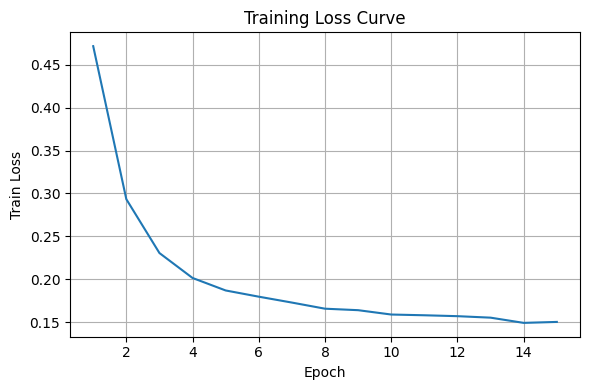

Saved: /content/exports/figures/train_loss_curve.png


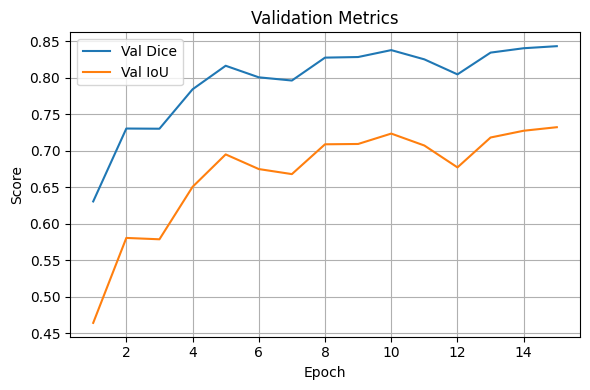

Saved: /content/exports/figures/val_metrics_curve.png


In [19]:
# ============================================================
# 12.1) EĞİTİM EĞRİLERİ (SUNUMA HAZIR)
# ============================================================
import matplotlib.pyplot as plt

epochs = np.arange(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(6,4))
plt.plot(epochs, history["train_loss"])
plt.xlabel("Epoch")
plt.ylabel("Train Loss")
plt.title("Training Loss Curve")
plt.grid(True)
plt.tight_layout()
loss_fig_path = FIG_DIR / "train_loss_curve.png"
plt.savefig(loss_fig_path, dpi=200)
plt.show()
print("Saved:", loss_fig_path)

plt.figure(figsize=(6,4))
plt.plot(epochs, history["val_dice"], label="Val Dice")
plt.plot(epochs, history["val_iou"], label="Val IoU")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("Validation Metrics")
plt.grid(True)
plt.legend()
plt.tight_layout()
val_fig_path = FIG_DIR / "val_metrics_curve.png"
plt.savefig(val_fig_path, dpi=200)
plt.show()
print("Saved:", val_fig_path)


## 13) Test Değerlendirme (Final Performans)

Validation, eğitim sırasında model seçimi içindir.  
**Test seti ise eğitim sürecinden tamamen bağımsızdır** ve nihai performansı raporlamak için kullanılır.

Bu bölümde yaptıklarımız:
1. En iyi modeli (`best_unet.pt`) yüklemek
2. Test setindeki tüm görüntüler üzerinde metrikleri hesaplamak
3. Sonuçları hem:
   - **Genel özet (mean/std)**
   - **Görüntü bazlı (per-image) tablo**
şeklinde kaydetmek

### 13.1 Neden “Per-Image” Tablo Üretiyoruz?
Sadece tek bir ortalama skor vermek, modelin “hangi tür görüntülerde zorlandığını” saklar.
Görüntü bazlı tablo ile:
- En iyi ve en kötü örnekler seçilebilir (best/worst)
- Hata analizi görselleri için objektif seçim yapılır
- Sunumda model davranışı somutlaştırılır

### 13.2 Test Skorlarını Nasıl Okumalıyız?
- **Dice/IoU:** genel örtüşme kalitesini gösterir
- **Precision:** “fazla damar çizme” (FP) eğilimini yansıtır
- **Recall:** “damar kaçırma” (FN) eğilimini yansıtır

Segmentasyonda genellikle:
- Recall düşükse ince damarlar kaçıyor olabilir
- Precision düşükse model gürültüyü damar sanıyor olabilir


In [20]:
# ============================================================
# 13) BEST CHECKPOINT YÜKLE
# ============================================================
import torch

best_path = CKPT_DIR / "best_unet.pt"
assert best_path.exists(), f"Checkpoint yok: {best_path}"

ckpt = torch.load(best_path, map_location=device)
model.load_state_dict(ckpt["model_state"])
model.to(device)
model.eval()

print("Loaded BEST checkpoint from:", best_path)
print("Best val_dice recorded:", ckpt.get("best_dice", None))
print("Epoch:", ckpt.get("epoch", None))


Loaded BEST checkpoint from: /content/checkpoints/best_unet.pt
Best val_dice recorded: 0.8432883997758229
Epoch: 15


In [21]:
# ============================================================
# 13.1) TEST METRİKLERİ (GENEL + GÖRÜNTÜ BAZLI)
# ============================================================
import pandas as pd
from tqdm import tqdm

@torch.no_grad()
def compute_metrics_per_image(logits, targets, fov, thr=0.5, eps=1e-7):
    """
    Batch içindeki her görüntü için ayrı metrik üretir.
    (Dice/IoU/Precision/Recall + TP/FP/FN sayıları)
    """
    probs = torch.sigmoid(logits)
    preds = (probs > thr).float()

    B = preds.size(0)
    rows = []
    for b in range(B):
        p = preds[b:b+1]      # (1,1,H,W)
        t = targets[b:b+1]
        fv = fov[b:b+1]

        # FOV içindeki pikselleri seç
        p_vec = masked_flatten(p, fv)
        t_vec = masked_flatten(t, fv)

        tp = (p_vec * t_vec).sum()
        fp = (p_vec * (1 - t_vec)).sum()
        fn = ((1 - p_vec) * t_vec).sum()

        precision = (tp + eps) / (tp + fp + eps)
        recall    = (tp + eps) / (tp + fn + eps)
        dice      = (2*tp + eps) / (2*tp + fp + fn + eps)
        iou       = (tp + eps) / (tp + fp + fn + eps)

        rows.append({
            "dice": float(dice.item()),
            "iou": float(iou.item()),
            "precision": float(precision.item()),
            "recall": float(recall.item()),
            "tp": float(tp.item()),
            "fp": float(fp.item()),
            "fn": float(fn.item())
        })
    return rows

test_rows = []

for x, y, fv, stems in tqdm(test_loader, desc="test"):
    x = x.to(device, non_blocking=True)
    y = y.to(device, non_blocking=True)
    fv = fv.to(device, non_blocking=True)

    logits = model(x)
    per_img = compute_metrics_per_image(logits, y, fv, thr=0.5)

    # her görüntüye stem ekle
    for i, stem in enumerate(stems):
        row = {"stem": stem}
        row.update(per_img[i])
        test_rows.append(row)

df_test = pd.DataFrame(test_rows)

# Genel özet
summary = df_test[["dice","iou","precision","recall"]].agg(["mean","std"]).T
print("TEST SUMMARY (mean/std):")
print(summary)

# Kaydet
test_csv_path = TAB_DIR / "test_metrics_per_image.csv"
summary_csv_path = TAB_DIR / "test_metrics_summary.csv"

df_test.to_csv(test_csv_path, index=False)
summary.to_csv(summary_csv_path)

print("Saved:", test_csv_path)
print("Saved:", summary_csv_path)


test: 100%|██████████| 50/50 [01:06<00:00,  1.33s/it]


TEST SUMMARY (mean/std):
               mean       std
dice       0.820241  0.077327
iou        0.701779  0.100536
precision  0.870951  0.054073
recall     0.784116  0.109326
Saved: /content/exports/tables/test_metrics_per_image.csv
Saved: /content/exports/tables/test_metrics_summary.csv


## 14) Görsel İnceleme: Overlay ve Hata Haritaları (TP / FP / FN)

Sayısal metrikler tek başına yeterli değildir. Segmentasyonun en kritik kısmı:
> Model nerede doğru, nerede yanlış yapıyor?

Bu nedenle sunum ve raporda kullanılmak üzere şu görseller üretilir:

1. **GT Mask:** Uzman anotasyonu (yer doğrusu)
2. **Pred Mask:** Modelin tahmini
3. **GT Overlay:** GT damarları giriş görüntüsü üzerinde kırmızı gösterilir
4. **Pred Overlay:** Tahmin damarları giriş görüntüsü üzerinde kırmızı gösterilir
5. **Error Map (Hata Haritası):**
   - **TP (doğru damar)** = Yeşil
   - **FP (fazla damar)** = Kırmızı
   - **FN (kaçan damar)** = Mavi

### 14.1 Best/Worst Örnekler Neye Göre Seçildi?
Bu notebook’ta örnekler, test setinde hesaplanan **Dice skoruna göre** seçilir:
- En yüksek Dice: “best” örnekler (modelin güçlü olduğu durumlar)
- En düşük Dice: “worst” örnekler (modelin zorlandığı durumlar)

Bu seçim objektiftir (rastgele veya elle seçme değil).

### 14.2 Random Örnekler (Cherry-Picking Önleme)
Ek olarak test setinden rastgele örnekler seçilip aynı görseller üretilir.
Bu sayede modelin “sadece iyi örneklerde” değil genel olarak nasıl davrandığı gösterilir.


Selected stems: ['122_G', '123_G', '171_N', '160_N', '159_N', '112_G', '104_G', '136_G', '51_D', '140_G']


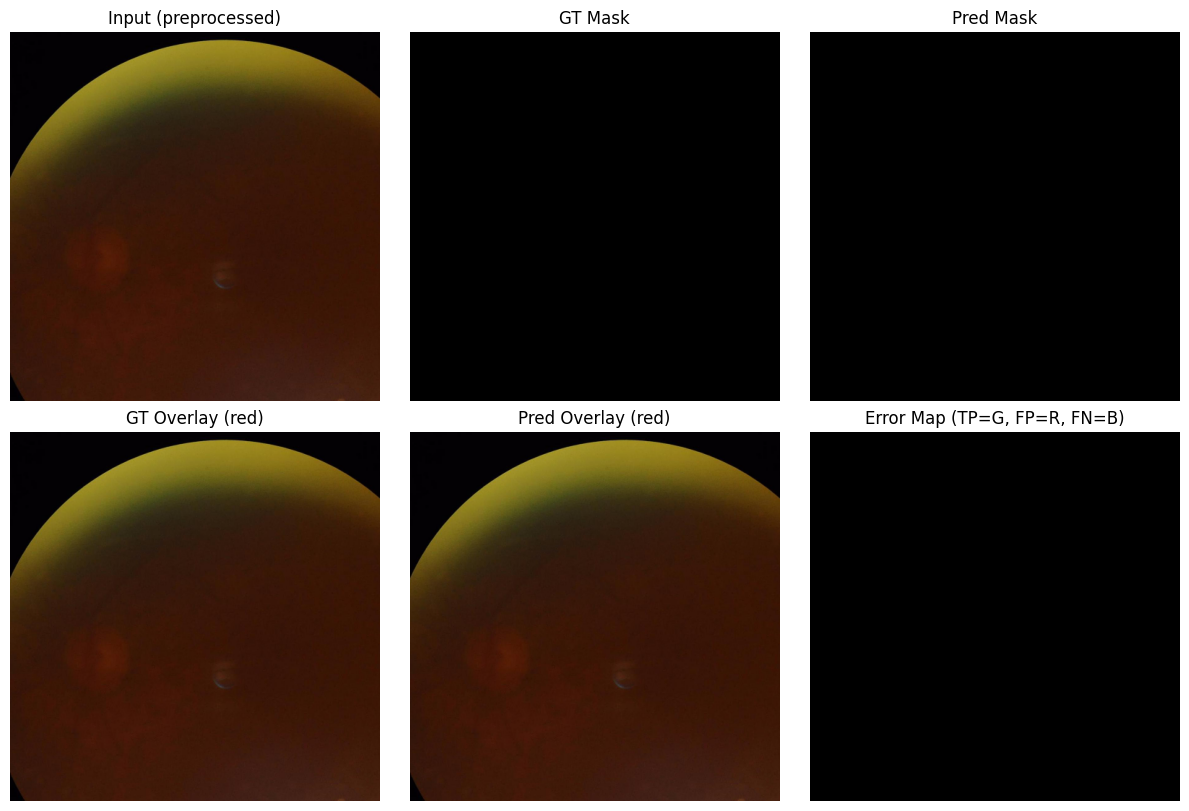

Saved: /content/exports/figures/test_vis_122_G.png
Saved pred mask: /content/exports/preds/122_G_pred.png


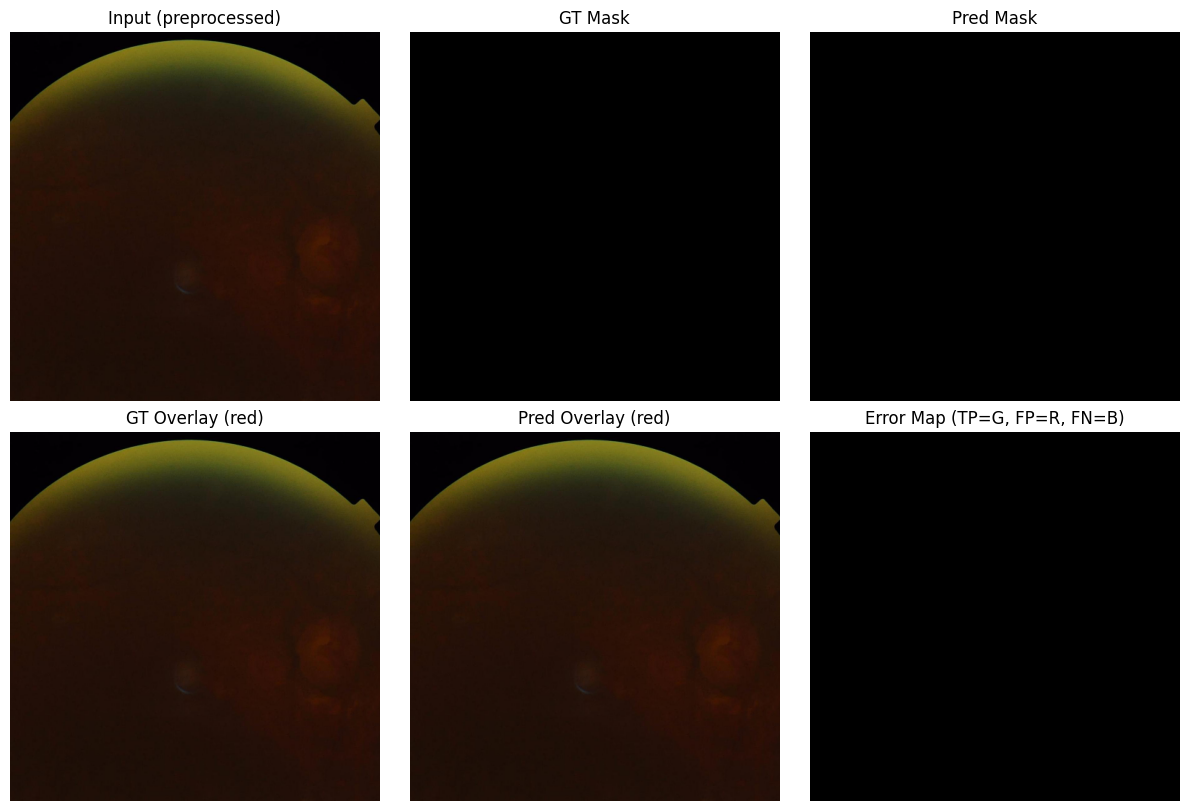

Saved: /content/exports/figures/test_vis_123_G.png
Saved pred mask: /content/exports/preds/123_G_pred.png


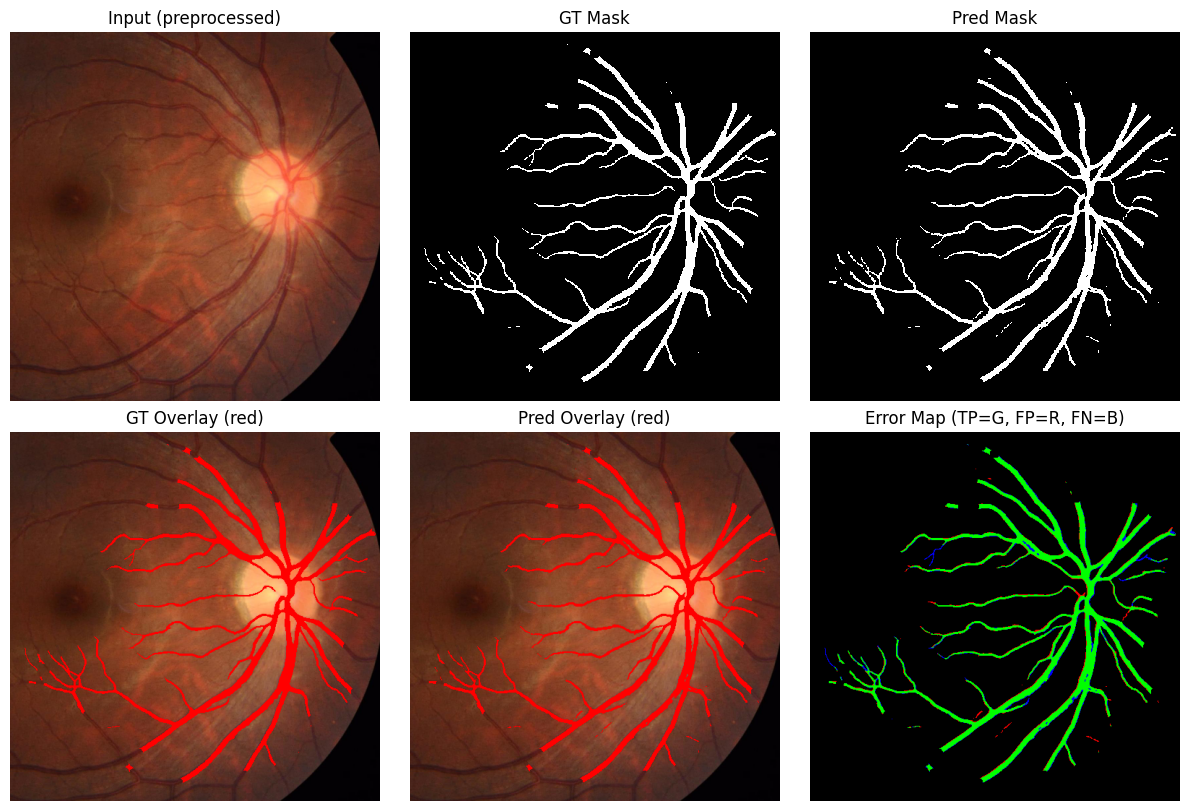

Saved: /content/exports/figures/test_vis_171_N.png
Saved pred mask: /content/exports/preds/171_N_pred.png


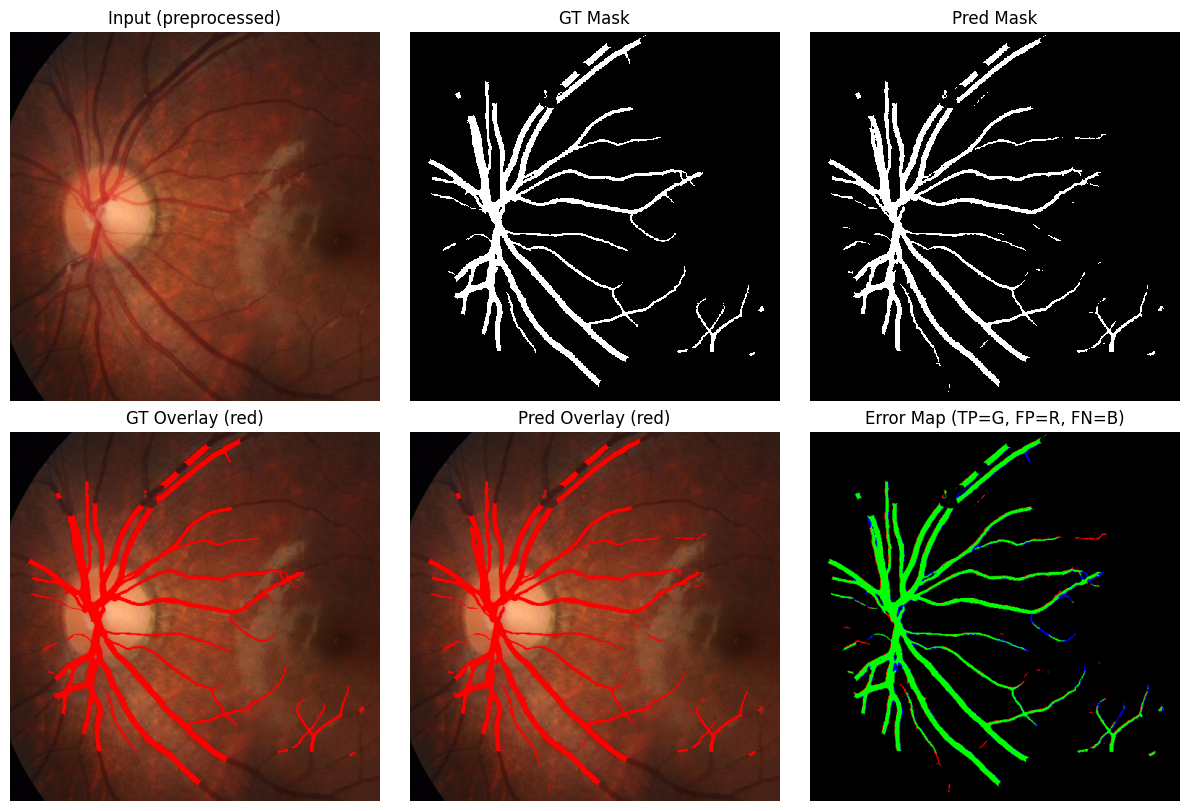

Saved: /content/exports/figures/test_vis_160_N.png
Saved pred mask: /content/exports/preds/160_N_pred.png


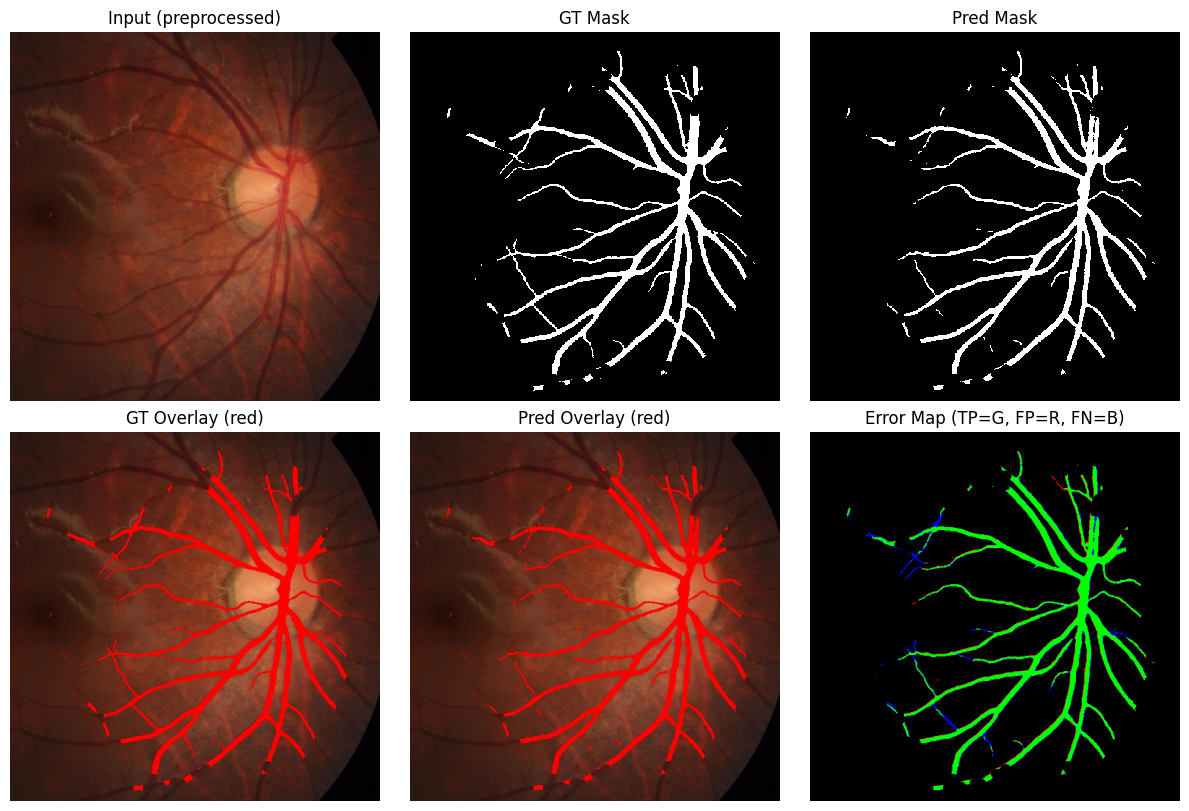

Saved: /content/exports/figures/test_vis_159_N.png
Saved pred mask: /content/exports/preds/159_N_pred.png


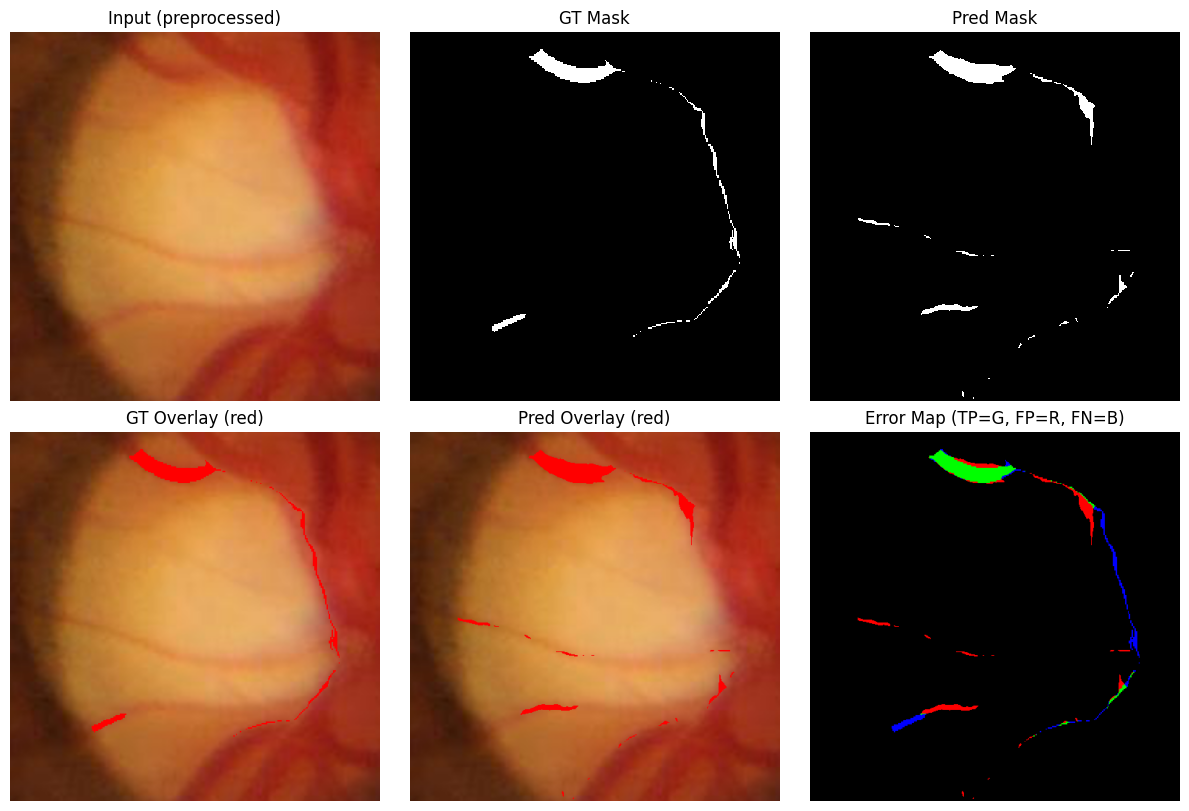

Saved: /content/exports/figures/test_vis_112_G.png
Saved pred mask: /content/exports/preds/112_G_pred.png


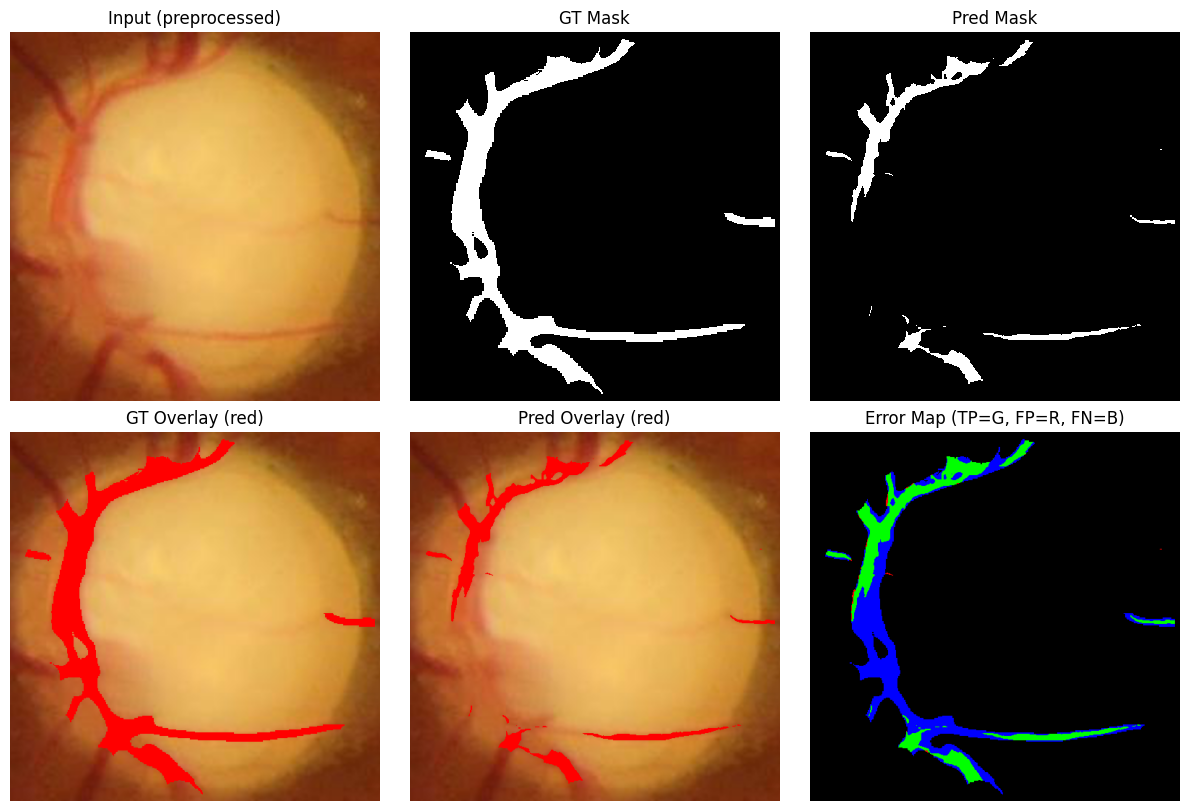

Saved: /content/exports/figures/test_vis_104_G.png
Saved pred mask: /content/exports/preds/104_G_pred.png


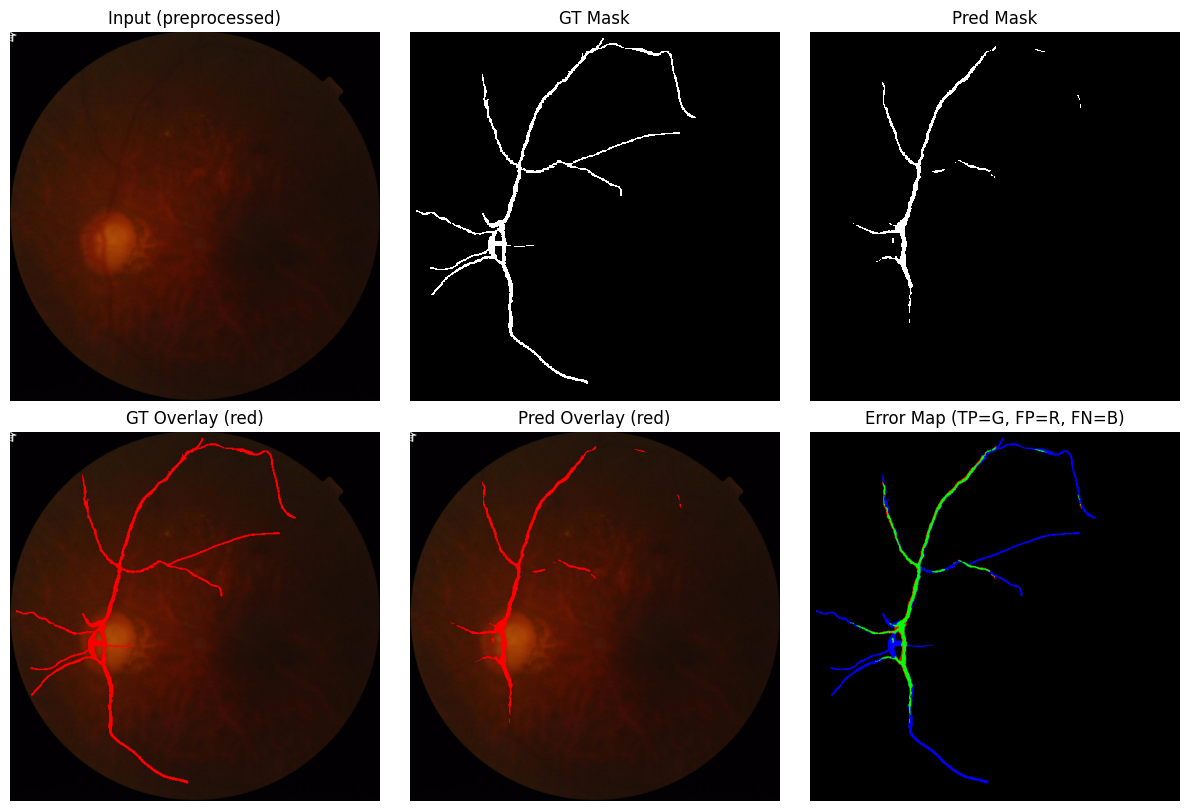

Saved: /content/exports/figures/test_vis_136_G.png
Saved pred mask: /content/exports/preds/136_G_pred.png


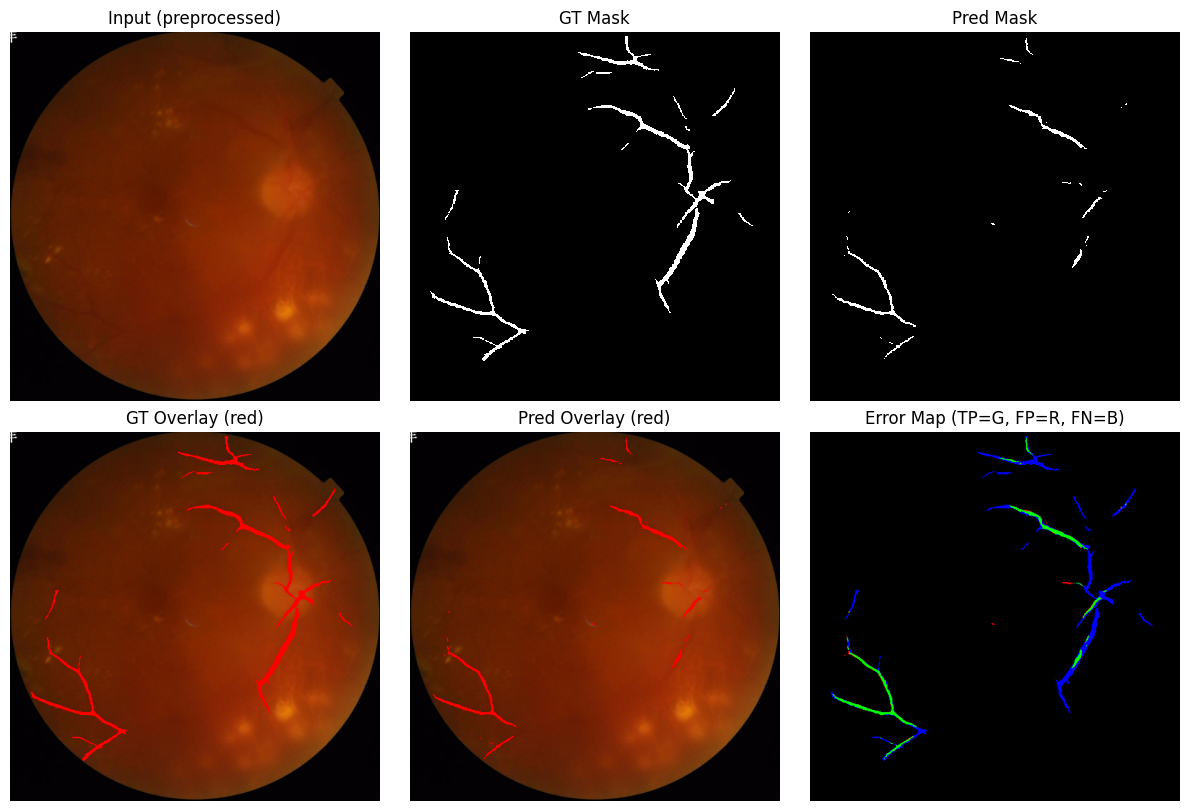

Saved: /content/exports/figures/test_vis_51_D.png
Saved pred mask: /content/exports/preds/51_D_pred.png


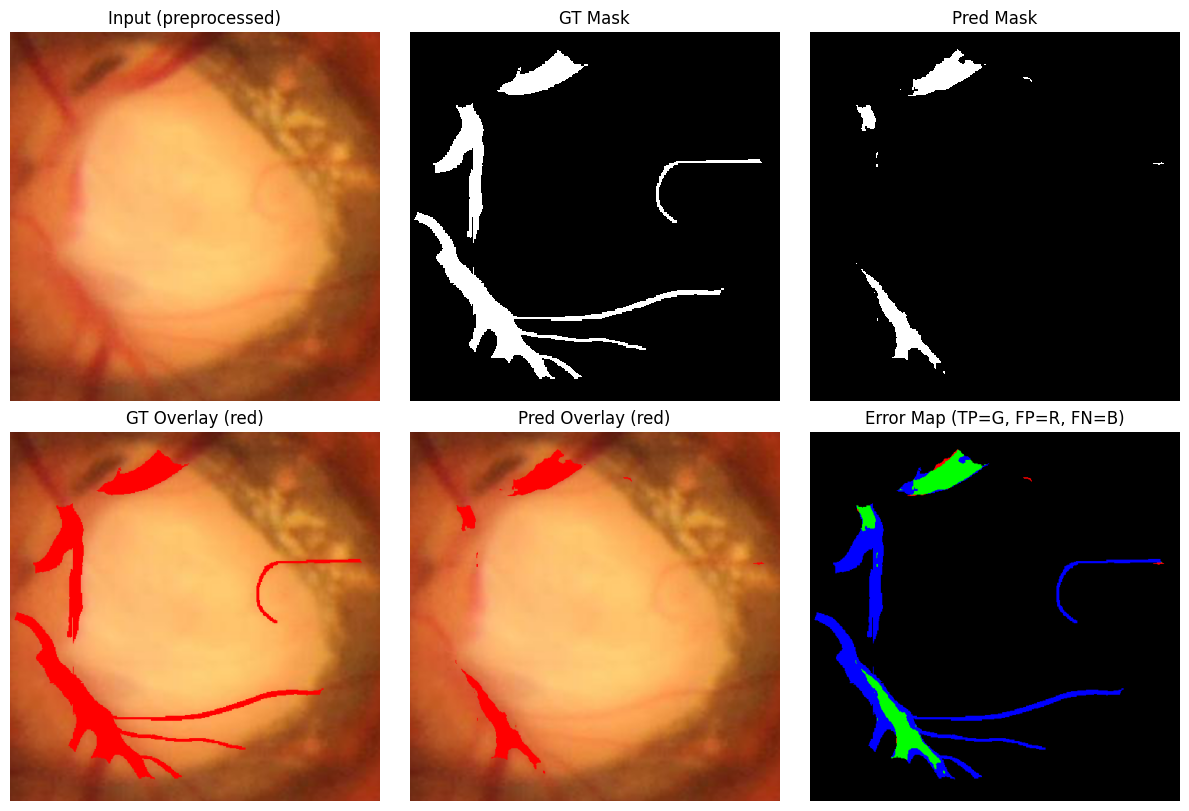

Saved: /content/exports/figures/test_vis_140_G.png
Saved pred mask: /content/exports/preds/140_G_pred.png


In [22]:
# ============================================================
# 14) ÖRNEK GÖRSELLERİ ÜRET (best/worst) - DÜZELTİLMİŞ
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import cv2
import torch

# 1) En iyi / en kötü örnekleri seç (Dice'a göre)
df_sorted = df_test.sort_values("dice", ascending=False).reset_index(drop=True)
top_k = 5
worst_k = 5

selected_stems = list(df_sorted.head(top_k)["stem"]) + list(df_sorted.tail(worst_k)["stem"])
print("Selected stems:", selected_stems)

# 2) Stem -> (img_path, msk_path) map'leri (test setinden)
test_pairs_map = {s: (img_p, msk_p) for (img_p, msk_p, s) in test_pairs}

def save_visuals_for_stem(stem, out_dir: Path, thr=0.5, dpi=300, show=True):
    """
    Tek bir test örneği için:
    - preprocess (rgb, gt, fov)
    - model pred
    - overlay + error map
    - fig olarak kaydet + pred mask kaydet
    """
    img_path, msk_path = test_pairs_map[stem]
    rgb, gt, fov = preprocess_pair(img_path, msk_path, out_size=IMG_SIZE)

    # tensöre çevir
    x = to_tensor_image(rgb).unsqueeze(0).to(device)  # (1,3,H,W)
    with torch.no_grad():
        logits = model(x)
        probs = torch.sigmoid(logits)[0,0].cpu().numpy()
    pred = (probs > thr).astype(np.uint8)

    # FOV dışını 0'la
    pred_f = pred * fov
    gt_f   = gt * fov

    # Overlay'ler
    gt_overlay = rgb.copy()
    gt_overlay[gt_f == 1] = [255, 0, 0]

    pred_overlay = rgb.copy()
    pred_overlay[pred_f == 1] = [255, 0, 0]

    # Error map (TP=G, FP=R, FN=B) - daha okunur olsun diye siyah zemin
    error = np.zeros_like(rgb)
    tp = (pred_f == 1) & (gt_f == 1)
    fp = (pred_f == 1) & (gt_f == 0)
    fn = (pred_f == 0) & (gt_f == 1)
    error[tp] = [0, 255, 0]
    error[fp] = [255, 0, 0]
    error[fn] = [0, 0, 255]

    # Fig (daha büyük + constrained_layout)
    fig, axes = plt.subplots(2, 3, figsize=(12, 8), constrained_layout=True)

    axes[0,0].imshow(rgb)
    axes[0,0].set_title("Input (preprocessed)")
    axes[0,0].axis("off")

    axes[0,1].imshow(gt_f, cmap="gray", interpolation="nearest", vmin=0, vmax=1)
    axes[0,1].set_title("GT Mask")
    axes[0,1].axis("off")

    axes[0,2].imshow(pred_f, cmap="gray", interpolation="nearest", vmin=0, vmax=1)
    axes[0,2].set_title("Pred Mask")
    axes[0,2].axis("off")

    axes[1,0].imshow(gt_overlay)
    axes[1,0].set_title("GT Overlay (red)")
    axes[1,0].axis("off")

    axes[1,1].imshow(pred_overlay)
    axes[1,1].set_title("Pred Overlay (red)")
    axes[1,1].axis("off")

    axes[1,2].imshow(error)
    axes[1,2].set_title("Error Map (TP=G, FP=R, FN=B)")
    axes[1,2].axis("off")

    out_path = out_dir / f"test_vis_{stem}.png"
    plt.savefig(out_path, dpi=dpi, bbox_inches="tight", pad_inches=0.02)

    if show:
        plt.show()
    plt.close(fig)

    print("Saved:", out_path)

    # Pred mask kaydı (0/255 PNG) - netlik için
    pred_png = (pred_f * 255).astype(np.uint8)
    pred_path = PRED_DIR / f"{stem}_pred.png"
    cv2.imwrite(str(pred_path), pred_png)
    print("Saved pred mask:", pred_path)

# üret
for s in selected_stems:
    save_visuals_for_stem(s, FIG_DIR)


Random selected stems: ['126_G']

[126_G] Dice=0.8282 IoU=0.7068 P=0.8445 R=0.8127 | TP=12666 FP=2333 FN=2920


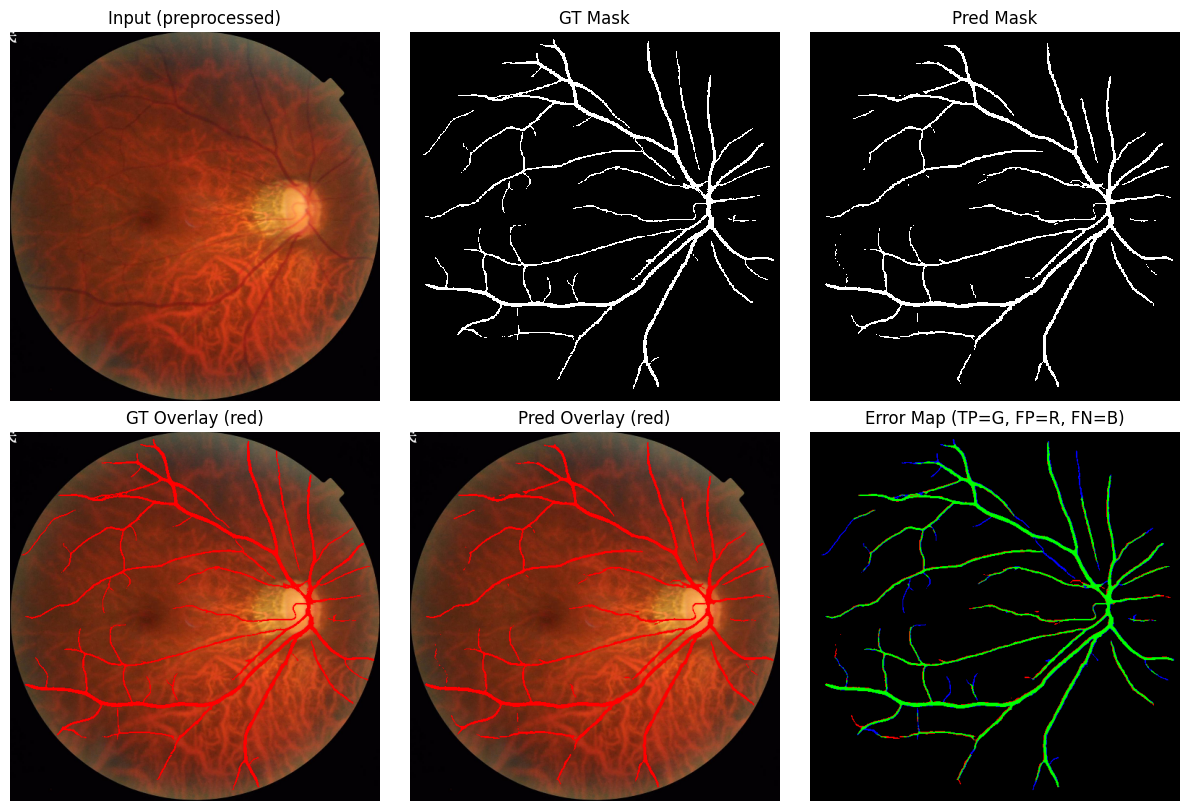

Saved: /content/exports/figures/test_vis_126_G.png
Saved pred mask: /content/exports/preds/126_G_pred.png


In [24]:
# ============================================================
# 14.2) RANDOM TEST VISUAL CHECK (2-4 örnek)
# ============================================================
import random
import torch

def random_test_visuals(n=3, thr=0.5, seed=None, show=True):
    stems = list(test_pairs_map.keys())
    if seed is not None:
        random.seed(seed)

    n = min(n, len(stems))
    chosen = random.sample(stems, k=n)
    print("Random selected stems:", chosen)

    for stem in chosen:
        img_path, msk_path = test_pairs_map[stem]
        rgb, gt, fov = preprocess_pair(img_path, msk_path, out_size=IMG_SIZE)

        # tensörler (metric hesabı için)
        x  = to_tensor_image(rgb).unsqueeze(0).to(device)                 # (1,3,H,W)
        y  = to_tensor_mask(gt).unsqueeze(0).to(device)                   # (1,1,H,W)
        fv = to_tensor_mask(fov).unsqueeze(0).to(device)                  # (1,1,H,W)

        with torch.no_grad():
            logits = model(x)

        # metrikler (FOV içinde)
        m = compute_metrics(logits, y, fv, thr=thr)

        # TP/FP/FN (FOV içinde)
        with torch.no_grad():
            probs = torch.sigmoid(logits)
            preds = (probs > thr).float()
            p_vec = masked_flatten(preds, fv)
            t_vec = masked_flatten(y, fv)

            tp = float((p_vec * t_vec).sum().item())
            fp = float((p_vec * (1 - t_vec)).sum().item())
            fn = float(((1 - p_vec) * t_vec).sum().item())

        print(f"\n[{stem}] Dice={m['dice']:.4f} IoU={m['iou']:.4f} P={m['precision']:.4f} R={m['recall']:.4f} | TP={tp:.0f} FP={fp:.0f} FN={fn:.0f}")

        # görselleştirme aynı fonksiyonla
        save_visuals_for_stem(stem, FIG_DIR, thr=thr, dpi=300, show=show)

# 3 örnek dene (istersen 2/4 yap)
random_test_visuals(n=1, thr=0.5, seed=None, show=True)


## 15) Damar Analizi (Segmentasyondan Nicel Ölçüm Üretme)

Bu proje teşhis yapmaz; ancak segmentasyon maskesi üzerinden temel damar metrikleri çıkarır.
Bu metrikler, daha ileri klinik/araştırma çalışmalarının temel yapı taşlarıdır.

Bu bölümde hem **GT** hem **Model Tahmini** için metrik hesaplayıp karşılaştırıyoruz.

### 15.1 Vessel Density (Damar Yoğunluğu)
FOV içindeki damar piksel oranı:
- Damar ağı “ne kadar yoğun?” sorusunun en temel yanıtı.
- Segmentasyon maskesi üzerinden doğrudan hesaplanır.

### 15.2 Skeleton Length (İskelet Uzunluğu)
Damar maskesi 1-piksel genişliğinde bir iskelete indirgenir (skeletonize).
- Toplam iskelet piksel sayısı → damar ağının “uzunluk” göstergesi.
- İnce damarların yakalanması/kaçırılması bu metriği etkiler.

### 15.3 Branch Points (Dallanma Noktaları)
Skeleton üzerinde komşuluk ilişkileri kullanılarak dallanma/junction sayısı hesaplanır.
- Damar ağının bağlantısallığı ve kompleksliği hakkında temel bir göstergedir.

### 15.4 Neden GT ve Pred’i Birlikte Analiz Ediyoruz?
Modelin GT’den “daha fazla damar çizmesi” gibi durumlar:
- Metriklerde FP artışı olarak cezalandırılabilir
- Ancak damar analizinde density / skeleton / branch değerlerini artırabilir

Bu yüzden:
- Sadece Dice gibi tek bir skor değil,
- **GT vs Pred damar analizi farkları** da raporlanır.
Bu bölüm, model çıktısının pratikte ne anlama geldiğini tartışma açısından projeyi güçlendirir.


In [25]:
# ============================================================
# 15) DAMAR ANALİZİ: density + skeleton length + branch points
# ============================================================
from skimage.morphology import skeletonize

def vessel_density(mask, fov, eps=1e-7):
    mask = (mask > 0).astype(np.uint8)
    fov  = (fov > 0).astype(np.uint8)
    denom = fov.sum() + eps
    return float((mask * fov).sum() / denom)

def skeleton_length(mask, fov):
    """
    skeleton pixel sayısı (FOV içinde).
    """
    mask = (mask > 0).astype(np.uint8) * (fov > 0).astype(np.uint8)
    skel = skeletonize(mask.astype(bool)).astype(np.uint8)
    return int(skel.sum()), skel

def branch_points_count(skel):
    """
    Skeleton üzerindeki dallanma noktaları:
    - Bir skeleton pikselinin komşu skeleton piksel sayısı >= 3 ise branch point sayılır.
    """
    skel_u = skel.astype(np.uint8)
    kernel = np.ones((3,3), dtype=np.uint8)

    # 3x3 komşulukta kaç skeleton piksel var?
    neigh = cv2.filter2D(skel_u, -1, kernel)  # merkez dahil
    neigh = neigh - skel_u  # merkez hariç komşu sayısı

    # branch: skeleton pixel ve komşu >= 3
    branch = (skel_u == 1) & (neigh >= 3)
    return int(branch.sum())

analysis_rows = []

# Test örneklerinin tamamı üzerinden analiz (200 adet)
for s in tqdm([r["stem"] for r in test_rows], desc="analysis"):
    img_path, msk_path = test_pairs_map[s]
    rgb, gt, fov = preprocess_pair(img_path, msk_path, out_size=IMG_SIZE)

    # pred üret
    x = to_tensor_image(rgb).unsqueeze(0).to(device)
    with torch.no_grad():
        logits = model(x)
        probs = torch.sigmoid(logits)[0,0].cpu().numpy()
    pred = (probs > 0.5).astype(np.uint8)

    # FOV içinde değerlendir
    gt_f = gt * fov
    pr_f = pred * fov

    # Density
    den_gt = vessel_density(gt_f, fov)
    den_pr = vessel_density(pr_f, fov)

    # Skeleton length + branch
    sk_len_gt, sk_gt = skeleton_length(gt_f, fov)
    sk_len_pr, sk_pr = skeleton_length(pr_f, fov)

    br_gt = branch_points_count(sk_gt)
    br_pr = branch_points_count(sk_pr)

    analysis_rows.append({
        "stem": s,
        "density_gt": den_gt,
        "density_pred": den_pr,
        "density_diff(pred-gt)": den_pr - den_gt,
        "skel_len_gt(px)": sk_len_gt,
        "skel_len_pred(px)": sk_len_pr,
        "skel_len_diff(px)": sk_len_pr - sk_len_gt,
        "branch_gt": br_gt,
        "branch_pred": br_pr,
        "branch_diff(pred-gt)": br_pr - br_gt,
    })

df_analysis = pd.DataFrame(analysis_rows)

analysis_csv_path = TAB_DIR / "vessel_analysis_gt_vs_pred.csv"
df_analysis.to_csv(analysis_csv_path, index=False)
print("Saved:", analysis_csv_path)

# kısa özet (sunuma koymalık)
summary_analysis = df_analysis.drop(columns=["stem"]).agg(["mean","std"]).T
print("\nANALYSIS SUMMARY (mean/std):")
print(summary_analysis)

summary_path = TAB_DIR / "vessel_analysis_summary.csv"
summary_analysis.to_csv(summary_path)
print("Saved:", summary_path)


analysis: 100%|██████████| 200/200 [01:30<00:00,  2.22it/s]

Saved: /content/exports/tables/vessel_analysis_gt_vs_pred.csv

ANALYSIS SUMMARY (mean/std):
                              mean          std
density_gt                0.102824     0.039192
density_pred              0.093593     0.036345
density_diff(pred-gt)    -0.009231     0.014211
skel_len_gt(px)        4830.675000  1923.359811
skel_len_pred(px)      4188.830000  1757.925491
skel_len_diff(px)      -641.845000   426.679338
branch_gt               277.445000   139.569572
branch_pred             195.445000   110.885594
branch_diff(pred-gt)    -82.000000    72.517958
Saved: /content/exports/tables/vessel_analysis_summary.csv


## 16) Çıktıları Toplama ve Kalıcı Hale Getirme (Exports + Drive)

Colab ortamında `/content` dizini **geçicidir**:
- Runtime kapanırsa model ve çıktılar kaybolabilir.

Bu nedenle proje sonunda üretilen tüm çıktılar iki klasörde toplanır:
- `checkpoints/` → en iyi model ağırlıkları (`best_unet.pt`)
- `exports/` → rapor/sunum için tüm çıktı dosyaları:
  - `figures/` (grafikler, overlay’ler, error map’ler)
  - `preds/` (tahmin maskeleri)
  - `tables/` (test metrik CSV’leri ve damar analizi CSV’leri)

Sunum günü yeniden eğitim yapmak istemiyoruz. Bu nedenle:
- `checkpoints/` ve `exports/` klasörleri **Google Drive’a kopyalanır**.
- Derste yalnızca:
  1) Drive’dan checkpoint’i yükleyip
  2) rastgele test örneklerinde canlı inference ve görsel analiz gösterilir.

Bu yaklaşım, demo sırasında “sıfırdan eğitim” riskini ortadan kaldırır.


In [26]:
# ============================================================
# 16) EXPORTS ZIP (indirmek için)
# ============================================================
import shutil

zip_path = "/content/exports_bundle"
shutil.make_archive(zip_path, 'zip', "/content/exports")
print("Created:", zip_path + ".zip")

# Colab'da indir
from google.colab import files
files.download(zip_path + ".zip")


Created: /content/exports_bundle.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [27]:
from google.colab import drive
drive.mount("/content/drive")

from pathlib import Path
import shutil

# Drive hedef klasör
DRIVE_ROOT = Path("/content/drive/MyDrive/Retina_Damar_Projesi")
DRIVE_ROOT.mkdir(parents=True, exist_ok=True)

# Kaynaklar
SRC_CKPT = Path("/content/checkpoints")
SRC_EXP  = Path("/content/exports")

# Hedefler
DST_CKPT = DRIVE_ROOT / "checkpoints"
DST_EXP  = DRIVE_ROOT / "exports"

# Varsa eski kopyaları sil
if DST_CKPT.exists():
    shutil.rmtree(DST_CKPT)
if DST_EXP.exists():
    shutil.rmtree(DST_EXP)

# Kopyala
shutil.copytree(SRC_CKPT, DST_CKPT)
shutil.copytree(SRC_EXP,  DST_EXP)

print("Copied to Drive:")
print(" -", DST_CKPT)
print(" -", DST_EXP)


Mounted at /content/drive
Copied to Drive:
 - /content/drive/MyDrive/Retina_Damar_Projesi/checkpoints
 - /content/drive/MyDrive/Retina_Damar_Projesi/exports


In [28]:
import random
import cv2
import numpy as np
from pathlib import Path

# Drive hedef klasör (senin kullandığın kökle aynı)
DEMO_DIR = Path("/content/drive/MyDrive/Retina_Damar_Projesi/demo_samples")
DEMO_DIR.mkdir(parents=True, exist_ok=True)

# Test stem listesi
all_stems = [s for (_,_,s) in test_pairs]
print("Total test stems:", len(all_stems))

# Kaç demo örneği kaydedelim?
N_DEMO = 15
chosen = random.sample(all_stems, k=min(N_DEMO, len(all_stems)))
print("Chosen demo stems:", chosen)

# Stem -> (img_path, msk_path)
test_pairs_map = {s: (img_p, msk_p) for (img_p, msk_p, s) in test_pairs}

for stem in chosen:
    img_path, msk_path = test_pairs_map[stem]

    # 512 preprocessed (RGB, GT 0/1, FOV 0/1)
    rgb, gt, fov = preprocess_pair(img_path, msk_path, out_size=IMG_SIZE)

    # RGB png olarak kaydetmek için BGR'ye çevir
    bgr = cv2.cvtColor(rgb, cv2.COLOR_RGB2BGR)

    cv2.imwrite(str(DEMO_DIR / f"{stem}_rgb.png"), bgr)
    cv2.imwrite(str(DEMO_DIR / f"{stem}_gt.png"),  (gt * 255).astype(np.uint8))
    cv2.imwrite(str(DEMO_DIR / f"{stem}_fov.png"), (fov * 255).astype(np.uint8))

print("Saved demo samples to:", DEMO_DIR)


Total test stems: 200
Chosen demo stems: ['106_G', '90_D', '164_N', '157_N', '152_N', '132_G', '8_A', '124_G', '76_D', '45_A', '120_G', '56_D', '199_N', '108_G', '107_G']
Saved demo samples to: /content/drive/MyDrive/Retina_Damar_Projesi/demo_samples


## 18) Sınırlılıklar ve Gelecek Geliştirmeler

Bu bölüm, projenin bilimsel olgunluğunu artırır: “ne yaptık” kadar “nerede sınırlıyız ve nasıl iyileştiririz” sorusunu da yanıtlar.

### 18.1 Sınırlılıklar
1. **GT anotasyonlarının doğası**
   - Uzman anotasyonları pratikte bazı ince damarları eksik temsil edebilir.
   - Modelin “GT’de olmayan ama görüntüde damar gibi görünen” yapıları işaretlemesi FP artışı olarak metriklere yansıyabilir.
   - Bu nedenle sayısal metrikler, overlay + error map gibi görsel analizlerle birlikte yorumlanmalıdır.

2. **Sabit threshold (0.5) kullanımı**
   - Eşik değeri, Precision/Recall dengesini değiştirir.
   - Daha yüksek eşik: FP azalır (Precision artar) fakat FN artabilir (Recall düşer).
   - Daha düşük eşik: Recall artabilir ancak FP artabilir.

3. **Çözünürlük düşürme (512×512)**
   - Hız ve bellek açısından avantajlıdır.
   - Ancak çok ince damar detaylarının bir kısmı kaybolabilir.
   - Bu proje, Colab hesaplama limitleri içinde “tüm görüntü” yaklaşımını tercih etmiştir.

4. **Baseline mimari kullanımı**
   - U-Net güçlü bir başlangıçtır; ancak daha iyi performans için gelişmiş varyantlar mümkündür.
   - Bu proje anlaşılabilirlik ve tekrar edilebilirliği önceliklemiştir.

### 18.2 Gelecek Geliştirmeler (Öneriler)
1. **Eşik optimizasyonu ve PR eğrisi**
   - Validation üzerinde threshold taraması yaparak en iyi Dice veya en iyi F1 (Dice) seçilebilir.
   - Precision–Recall trade-off daha sistematik gösterilebilir.

2. **Gelişmiş mimariler**
   - Attention U-Net, ResNet/ConvNeXt encoder’lı U-Net, multi-scale yapılar
   - İnce damarları yakalamayı iyileştirebilir.

3. **Kayıp fonksiyonu iyileştirmeleri**
   - Focal loss (zor örneklere odaklanma)
   - Tversky / Focal Tversky (FP–FN dengesini kontrol etme)

4. **Post-processing (segmentasyon sonrası düzeltme)**
   - Küçük gürültülerin temizlenmesi (morfolojik işlemler)
   - İnce damar sürekliliğini artırmak için bağlı bileşen/skeleton tabanlı düzeltmeler

5. **Daha zengin damar biyobelirteçleri**
   - Tortuozite (kıvrımlılık), damar kalınlığı profili, AVR (arter/ven oranı)
   - Daha gelişmiş klinik yorumlamaya giden yolu açar (teşhis değil, biyobelirteç çıkarımı).

Bu proje, segmentasyon + temel analiz katmanını tamamlayarak, daha ileri klinik karar destek sistemlerine ve nicel damar biyobelirteç çalışmalarına sağlam bir başlangıç sunar.
